In [3]:
%pylab inline
#code units
Mstar = 1
R0 = 1
G = 1
R_MU = 1

#cgs units
kB_CGS = 1.38064852e-16      # erg / K
mH_CGS = 2.4 * 1.67262192369e-24 # g (μ = 2.4)
Mstar_CGS = 1.9891e33            # g
G_CGS = 6.674e-8
AU_CM = 1.49597871e13
R0_CGS = 30.0 * AU_CM
R_MU_CGS = 36149835.0
gamma = 1.4

# ERGS macro for scale-free fondam (G=MSTAR=R0=1): one code energy unit [erg]
ergs_code = 1/((R0/R0_CGS) / ((G/G_CGS) * (Mstar/Mstar_CGS)**2))
Kelvin_code = ((G*Mstar/R0/R_MU)/(G_CGS*Mstar_CGS/R0_CGS/R_MU_CGS))

# k_B in code units ergs per kelvin
kB_code = kB_CGS * ergs_code/ Kelvin_code

# One particle mass in code units if 1 code mass = one stellar mass
mH_code = mH_CGS * (Mstar/ Mstar_CGS)


print(kB_code/ mH_code)


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
0.9514101616899104


In [ ]:
def plot_vz(folder, n):
    rmin = loadtxt("/Users/nadine/Downloads/fargo3d/outputs/" + folder +"/domain_y.dat")[3:-3]
    tmin = loadtxt("/Users/nadine/Downloads/fargo3d/outputs/" + folder +"/domain_z.dat")[3:-3]

    rmed = 0.5 * (rmin[1:] + rmin[:-1])
    tmed = 0.5 * (tmin[1:] + tmin[:-1])

    R, T = meshgrid(rmed, tmed)

    nz = 128
    ny = 128


    vthetan_th = fromfile("/Users/nadine/Downloads/fargo3d/outputs/" + folder+ "/gasvz{:d}.dat".format(n)).reshape(nz,ny)
    vthetan_d= fromfile("/Users/nadine/Downloads/fargo3d/outputs/" + folder +"/dust1vz{:d}.dat".format(n)).reshape(nz,ny)

    cg = R_MU /(gamma -1)
    cd = 0.088* cg


    H0 = 0.06
    fig = plt.figure(figsize=(12, 6))

    ax1 = fig.add_subplot(211)
    # surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
    surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

    ax1.set_xlabel('r (AU)')
    ax1.set_ylabel('z/H')
    ax1.set_xlim(0.6*60, 1.5*60)
    fig.colorbar(surf1, ax=ax1, label=r'$v_{\theta, gas}\, [\rm K]$')

    # fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

    ax2 = fig.add_subplot(212)
    surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.003,vmax=0.003)
    ax2.set_xlabel('r (AU)')
    ax2.set_ylabel('z/H')
    ax2.set_xlim(60*0.6,60*1.5)
    fig.colorbar(surf2, ax=ax2, label=r'$v_{\theta, dust}$')
    show()

In [5]:
n =6

vthetan_th = fromfile("../../outputs/vsi_128_iso/gasvz{:d}.dat".format(n)).reshape(nz,ny)
rhodn_th = fromfile("../../outputs/vsi_128_iso/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
edn_th = fromfile("../../outputs/vsi_128_iso/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
egn_th = fromfile("../../outputs/vsi_128_iso/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
rhogn_th = fromfile("../../outputs/vsi_128_iso/gasdens{:d}.dat".format(n)).reshape(nz,ny)

# tcol = fromfile("../../outputs/vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = gamma * R_MU /(gamma -1)
cd = 0.088* cg

Tdust = edn_th / rhodn_th / Kelvin_code / cd

Tgas = egn_th / rhogn_th / Kelvin_code / cg

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
print(np.mean(tcol))
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(60*R*sin(T),cos(T)/H0, Tdust, cmap='RdBu')

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(60*0.6, 60*1.5)
fig.colorbar(surf1, ax=ax1, label=r'$T_{\rm dust}\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, Tgas, cmap='RdBu')
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(60*0.6, 60*1.5)
fig.colorbar(surf2, ax=ax2, label=r'$T_{\rm gas} [K]$')
show()

NameError: name 'nz' is not defined

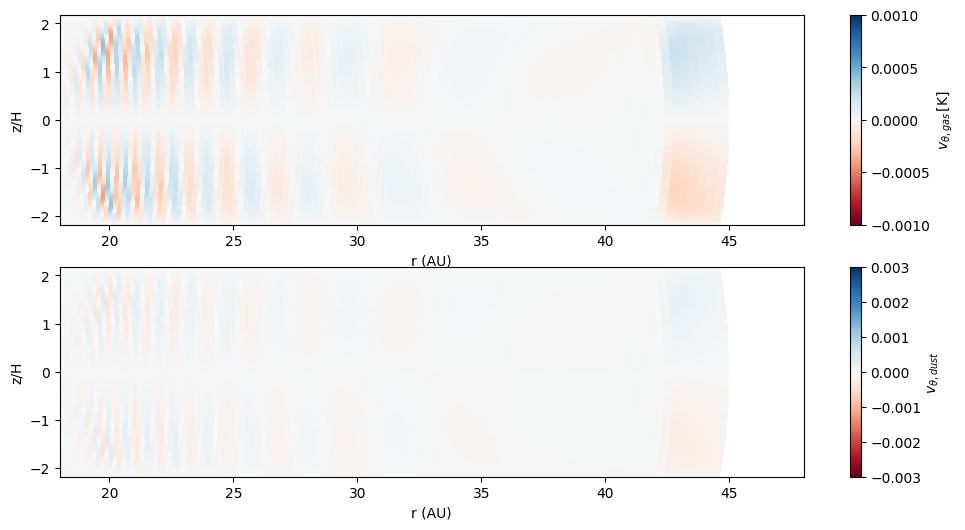

In [6]:
# plot_vz("vsi_128_iso", 100)
# plot_vz("vsi_128_adi", 100)
# plot_vz("vsi_sametemp", 100)
# plot_vz("vsi_diffT", 100)
# plot_vz("vsi_sameTgrad", 100)
plot_vz("vsi_60", 20)

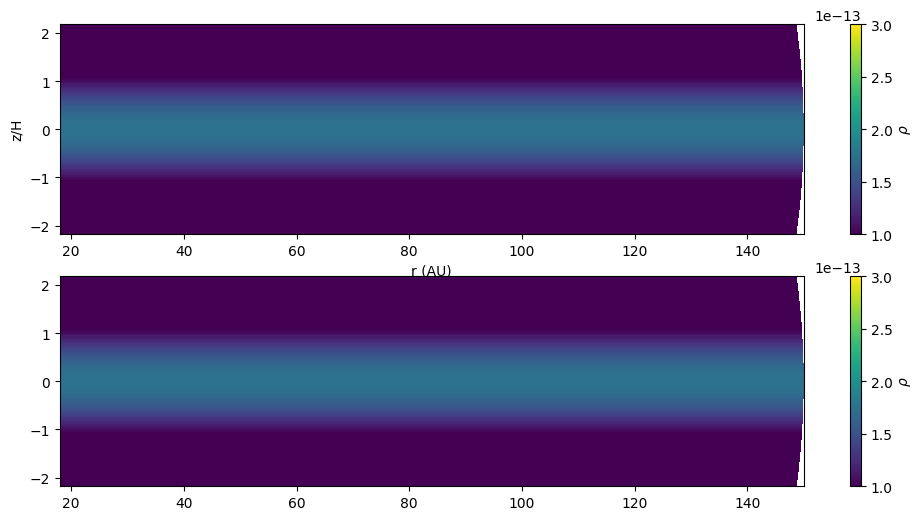

In [52]:
n =0
folder ="vsi_30"
rmin = loadtxt("/Users/nadine/Downloads/fargo3d/outputs/" + folder +"/domain_y.dat")[3:-3]
tmin = loadtxt("/Users/nadine/Downloads/fargo3d/outputs/" + folder +"/domain_z.dat")[3:-3]

rmed = 0.5 * (rmin[1:] + rmin[:-1])
tmed = 0.5 * (tmin[1:] + tmin[:-1])

R, T = meshgrid(rmed, tmed)

nz = 128
ny = 128

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

rho1 = fromfile("../../outputs/vsi_30/gasdens{:d}.dat".format(n)).reshape(nz,ny)
ax1 = fig.add_subplot(211)
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, rho1 *R**2* Mstar_CGS/(30 * AU_CM)**3, vmin = 1e-13, vmax = 3e-13)

folder ="vsi_100"
rmin = loadtxt("/Users/nadine/Downloads/fargo3d/outputs/" + folder +"/domain_y.dat")[3:-3]
tmin = loadtxt("/Users/nadine/Downloads/fargo3d/outputs/" + folder +"/domain_z.dat")[3:-3]
rmed = 0.5 * (rmin[1:] + rmin[:-1])
tmed = 0.5 * (tmin[1:] + tmin[:-1])
R, T = meshgrid(rmed, tmed)

rho2 = fromfile("../../outputs/vsi_100/gasdens{:d}.dat".format(n)).reshape(nz,ny)
ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(100*R*sin(T),cos(T)/H0, rho2 *(R*100/30)**2* Mstar_CGS/(100 * AU_CM)**3, vmin = 1e-13, vmax = 3e-13)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.5*100)
ax2.set_xlim(0.6*30, 1.5*100)
fig.colorbar(surf1, ax=ax1, label=r'$\rho$')
fig.colorbar(surf2, ax=ax2, label=r'$\rho $')

show()

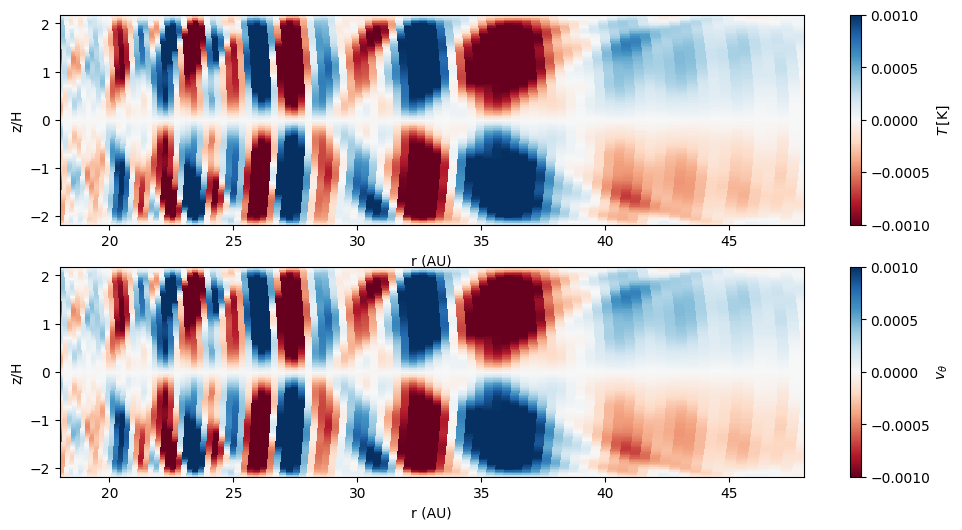

In [43]:
n =19

vthetan_th = fromfile("../../outputs/vsi_128_2fluid/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_128_2fluid/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg


H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

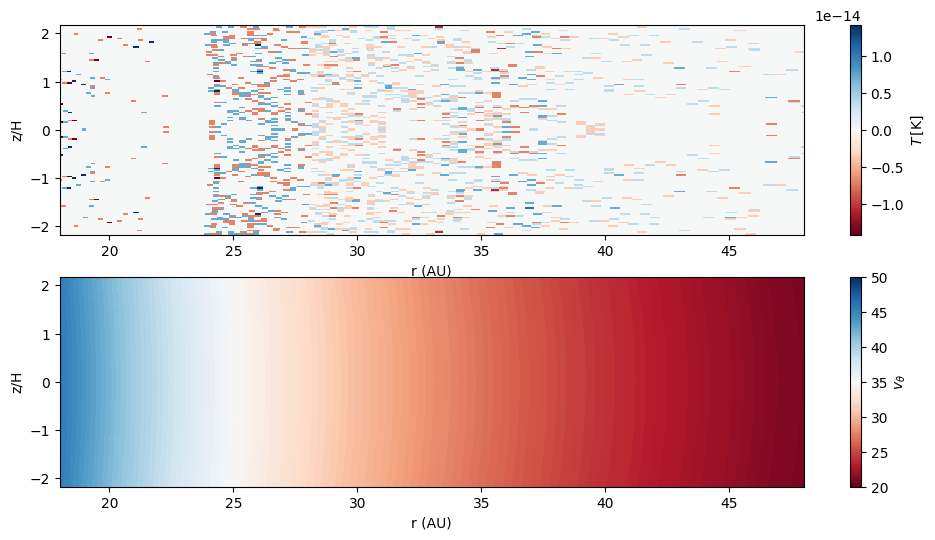

In [83]:
n =0

ed1 = fromfile("../../outputs/vsi_diffT/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
ed2= fromfile("../../outputs/vsi_diffT/dust2energy{:d}.dat".format(n)).reshape(nz,ny)
d1 = fromfile("../../outputs/vsi_diffT/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
d2= fromfile("../../outputs/vsi_diffT/dust2dens{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)




cg = R_MU /(gamma -1)
cd = 0.088* cg
T1 = ed1/d1/cd * temp_units
T2 = ed2/d2/cd * temp_units

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, T1-T2, cmap='RdBu')#, vmin=20,vmax=50)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, T2, cmap='RdBu', vmin=20,vmax=50)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

In [57]:
n = 50

tcol = fromfile("../../outputs/vsi_lin/Tcol{:d}.dat".format(n)).reshape(nz,ny)
H0 = 0.06

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm())
ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
# surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.0001,vmax=0.0001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/vsi_lin/Tcol50.dat'

Loaded data for Nsubth=6
Loaded data for Nsubth=1


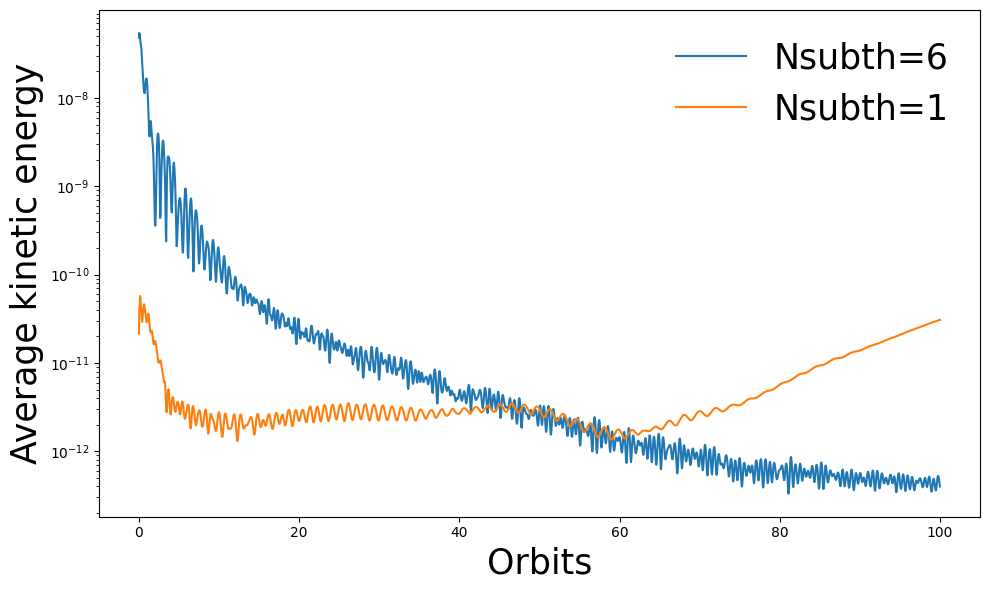

In [98]:
nofb = "../../outputs/vsi_sametemp"
nofb_1 = "../../outputs/vsi_diffT"

import numpy as np
import matplotlib.pyplot as plt
import os

nintern = 20
nout = 100  # base number, can customize per key if needed
ny = 128   # adjust this if your vertical grid size differs

paths = {
    "Nsubth=6": nofb,
    "Nsubth=1": nofb_1,
}

nout_dict = {
    "Nsubth=6": 100,
    "Nsubth=1": 100,
}


# storage for data
monitor_data = {}

# Read and process data for each simulation
for key, path in paths.items():
    try:
        ny = 128
        nx = 128
        nout_val = nout_dict.get(key, nout)
        E_file = os.path.join(path, "monitor/gas/kinetic_1d_Y_raw.dat")
        R_file = os.path.join(path, "monitor/gas/reynolds_1d_Y_raw.dat")

        E = np.fromfile(E_file)[:nout_val * nintern * ny].reshape(nout_val * nintern, ny)
        R = np.fromfile(R_file)[:nout_val * nintern * ny].reshape(nout_val * nintern, ny)
        time = np.linspace(0, 2 * np.pi * nout_val, nout_val * nintern)

        monitor_data[key] = {
            "E": E,
            "Reynolds": R,
            "time": time
        }

        print(f"Loaded data for {key}")

    except Exception as e:
        print(f"Skipping {key} due to error: {e}")

# --- Plot mean kinetic energy vs time ---
plt.figure(figsize=(10, 6))

for key, data in monitor_data.items():
    E = data["E"]
    time = data["time"]
    mean_E = np.nanmean(E[:, 128//8:-128//8], axis=1)
    plt.plot(time / (2 * np.pi), mean_E, label=key)

plt.yscale('log')
plt.ylabel('Average kinetic energy', fontsize=25)
plt.xlabel('Orbits', fontsize=25)
plt.legend(frameon=False, fontsize=25)
# plt.title('Evolution of Kinetic Energy vs Time for Each Simulation')
plt.tight_layout()
# plt.savefig("growthrate_T.pdf")
plt.show()


Processing same temperature
Processing different temperature


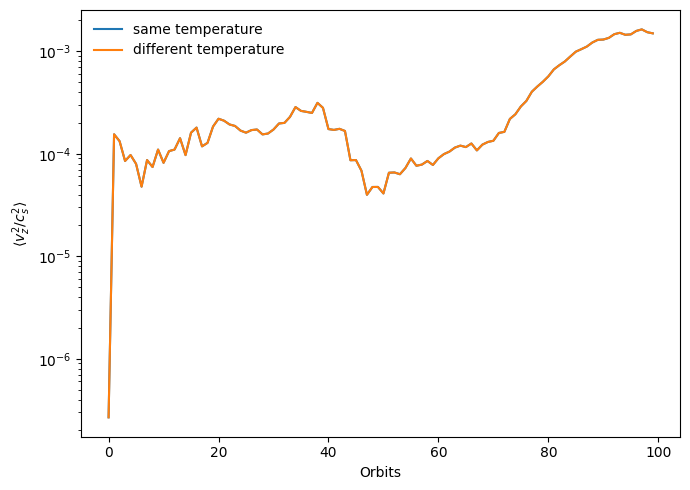

In [58]:
import numpy as np
import os
import matplotlib.pyplot as plt


# ==========================================================
# USER SETTINGS
# ==========================================================
r_target = 30.0      # AU
dR       = 3       # radial half-width (AU)
N        = 100       # number of outputs
fluidname = "gas"

k_B = 1.380649e-16       # erg/K
m_p = 1.6726219e-24      # g
mu = 2.4               # mean molecular weight for molecular gas
m_gas = mu * m_p
dust_internal_density = 2.0  # g/cm^3 (example)

period = 0.314159265359* 20    #time in code units for 1 whole period
amin = 1e-4 
NFLUIDS = 6
G_cgs = 6.674e-8
M_cgs =1.9891e33
R0_cgs = 30.0*1.49597871e13
Rmu_cgs = 36149835
mass_units = M_cgs
density_units = M_cgs / R0_cgs**3

temp_units = G_cgs*M_cgs/R0_cgs/Rmu_cgs   # from code units to cgs
k_B_units = G_cgs*M_cgs**2/R0_cgs / temp_units
# k_B_units = M_cgs* Rmu_cgs # is this correct
t_units = np.sqrt(G_cgs*M_cgs/R0_cgs**3)**(-1) 
rate_units = np.sqrt(G_cgs*M_cgs/R0_cgs**3)


aspect = 0.06
gamma =1.4
q = 1
nz, ny = 128, 128
H0 = 0.06

GAMMA = 1.4
cv = 1.0 / (GAMMA - 1.0)
# cp = GAMMA * cv
cd = 0.088 * cv
v_unit = R0_CGS/t_units


# List as many paths as you want
paths = {
    "same temperature": "../../outputs/vsi_sametemp/",
    "different temperature": "../../outputs/vsi_diffT/",
}

# ==========================================================
# LOAD GRID
# ==========================================================
def load_grid(path):
    rmin = np.loadtxt(path + "domain_y.dat")[3:-3]
    tmin = np.loadtxt(path + "domain_z.dat")[3:-3]

    rmed = 0.5 * (rmin[1:] + rmin[:-1])
    tmed = 0.5 * (tmin[1:] + tmin[:-1])

    R, T = np.meshgrid(rmed, tmed)

    r = 30 * R * np.sin(T)
    Z = np.cos(T) / H0

    return r, Z


# ==========================================================
# LOAD ONE SNAPSHOT
# ==========================================================
def load_snapshot(n, path, fluidname):

    dens = np.fromfile(f"{path}{fluidname}dens{n}.dat").reshape(nz, ny)
    ener = np.fromfile(f"{path}{fluidname}energy{n}.dat").reshape(nz, ny)
    vz   = np.fromfile(f"{path}{fluidname}vz{n}.dat").reshape(nz, ny)

    if fluidname == "gas":
        temp = ener / (dens * cv)
    else:
        temp = ener / (dens * cd)

    return dens, temp, vz


# ==========================================================
# COMPUTE TIME SERIES FOR ONE PATH
# ==========================================================
def compute_vz2_timeseries(path, fluidname):

    r, Z = load_grid(path)
    vz2_time = []

    for n in range(N):

        filename = f"{path}{fluidname}vz{n}.dat"
        if not os.path.exists(filename):
            continue

        dens, temp, vz = load_snapshot(n, path, fluidname)
        cs0 = np.sqrt(k_B  * temp * temp_units / (np.pi * m_gas)) /v_unit
        vz = vz/cs0
        H = 2.0

        radial_mask   = np.abs(r - r_target) < dR
#         radial_mask1   = r <45  
#         radial_mask2    = r> 22
        vertical_mask = np.abs(Z) <= H
#         mask = radial_mask1 & radial_mask2 & vertical_mask
        mask = radial_mask & vertical_mask

        
        if np.sum(mask) == 0:
            vz2_time.append(np.nan)
            continue

        vz2_avg = np.sum(dens[mask] * vz[mask]**2) / np.sum(dens[mask])
        vz2_avg = np.mean( vz[mask]**2)   #/ np.sum(dens[mask])
        vz2_time.append(vz2_avg)

    return np.array(vz2_time)



results = {}

for label, path in paths.items():
    print(f"Processing {label}")
    results[label] = compute_vz2_timeseries(path, fluidname)


plt.figure(figsize=(7,5))

dt = 1.0  # replace with real timestep

for label, series in results.items():
    time = np.arange(len(series)) * dt
    plt.semilogy(time, series, label=label)

plt.xlabel("Orbits")
plt.ylabel(r"$\langle v_z^2/c_s^2 \rangle$")
# plt.title(r"$\langle v_z^2 \rangle$ within 1H at R=30 AU")
plt.legend(frameon=False)
plt.tight_layout()
# plt.xlim(0, 79)
plt.savefig("vz2_vs_time_all_runs.pdf")
plt.show()

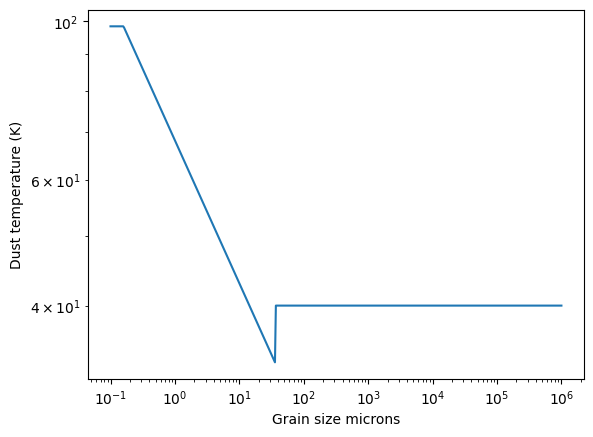

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- physical constants (CGS where needed, but ratios dominate here) ---
PLANCK = 6.626e-27      # erg s
C0 = 3.0e10             # cm/s
KBOLTZ = 1.38e-16       # erg/K
M_PI = np.pi

R0 = 1.0
R0_CGS = 1.0

# --- dust temperature function (translation of your C code) ---
def get_dust_temperature(teff, stokes_val):
    x = 2.0 * np.pi * stokes_val

    lambda_irr = 1e-4#0.29/teff

    grain_size_cgs = stokes_val 

    # Regime 1: Small grains
    if x < lambda_irr:
        return (PLANCK * C0 / (4.0 * (lambda_irr) * KBOLTZ))**0.2 * teff**0.8

    # Regime 2: Intermediate grains
    tdust = (PLANCK * C0 / (4.0 * (lambda_irr) * KBOLTZ))**0.2 * teff**0.8
    if grain_size_cgs < PLANCK * C0 / (4.0 * KBOLTZ * tdust):
        return (PLANCK * C0 / (8.0 * np.pi * grain_size_cgs * KBOLTZ))**0.2 * teff**0.8

    # Regime 3: Large grains
    return teff


# --- sweep grain size ---
teff = 40  # example stellar temperature in K

stokes_vals = np.logspace(-5, 2, 500)

temps = np.array([get_dust_temperature(teff, s) for s in stokes_vals])

# --- plot ---
plt.figure()
plt.loglog(stokes_vals*1e4, temps)
plt.xlabel("Grain size microns")
plt.ylabel("Dust temperature (K)")
plt.show()

0.02233044535436058 0.0036


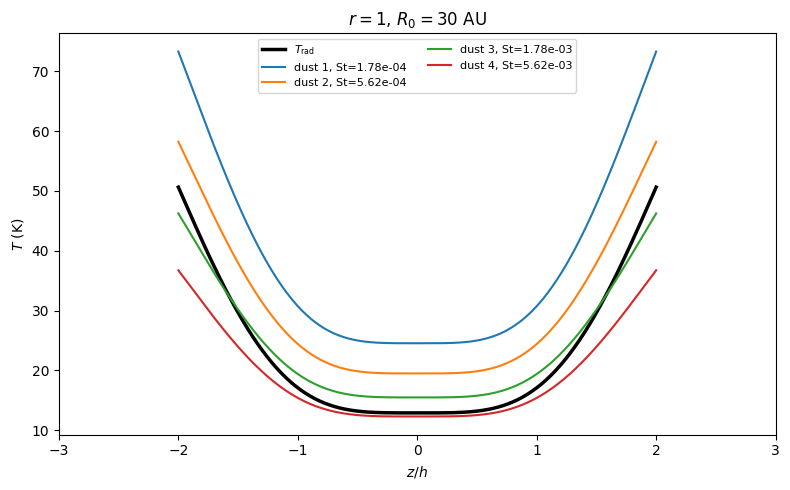

In [23]:
#!/usr/bin/env python3
# T_rad and T_dust vs z/h at r = 1. Linear script, no main().

import numpy as np
import matplotlib.pyplot as plt

# --- Code / cgs -------------------------------------------------
G = 1.0
MSTAR = 1.0
R0 = 1.0
R_MU = 1.0
r = 1.0

kb = 1.380649e-16
mh = 1.67262192369e-24
G_cgs = 6.67430e-8
MSTAR_cgs = 1.98847e33
R0_cgs = 30.0 * 1.495978707e13
R_MU_cgs = kb / mh
PLANCK = 6.62607015e-27
C0 = 2.99792458e10
KBOLTZ = kb

T_scale_K = (G_cgs * MSTAR_cgs / R0_cgs) / R_MU_cgs
TCMB_code = 2.73 / T_scale_K

ASPECTRATIO = 0.06
FLARINGINDEX = 0.0
USE_TEMPGRAD = True
LAMBDA_IRR = 1e-5
USE_DIFFTEMP = True

NFLUIDS = 5
SQ = 3.5
TSMIN, TSMAX = 1e-4, 1e-2

zh = np.linspace(-2.0, 2.0, 400)

# --- T_rad at r=1, code → K --------------------------------------
h = ASPECTRATIO * (r / R0) ** FLARINGINDEX
if USE_TEMPGRAD:
    Tunit = TCMB_code / 2.73
    Tatm = (80.0 ) * Tunit
    Tmid = h * h * G * MSTAR / r
    print(Tatm, Tmid)
    zq = 3.0
    Tr_code = Tmid + (Tatm - Tmid) * np.cos(np.pi / 2 * zh / zq + np.pi / 2.0) ** 4
else:
    Tr_code = h * h * G * MSTAR / r
Tr_K = Tr_code /Tunit

# --- one Stokes per dust bin (geometric mean of bin edges) ----------
Ndust = NFLUIDS - 1
ds = (np.log(TSMAX) - np.log(TSMIN)) / (NFLUIDS - 1)
edges = TSMIN * np.exp(ds * np.arange(NFLUIDS))
stokes = np.sqrt(edges[:-1] * edges[1:])
if NFLUIDS == 2:
    stokes = np.array([TSMAX])

# --- dust T(K): same branches as C, teff = Tr_K (array) ------------


def dust_T_K(teff_K, st):
    if not USE_DIFFTEMP:
        return teff_K
    teff_K = np.asarray(teff_K, dtype=float)
    x = 2.0 * np.pi * st
    grain_cm = st 
    denom1 = 4.0 * (LAMBDA_IRR ) * KBOLTZ
    T1 = (PLANCK * C0 / denom1) ** 0.2 * teff_K ** 0.8
    teff_safe = np.maximum(teff_K, 1e-300)
    wien_lim = PLANCK * C0 / (4.0 * KBOLTZ * teff_safe)
    T2 = (PLANCK * C0 / (8.0 * np.pi * grain_cm * KBOLTZ)) ** 0.2 * teff_K ** 0.8

    use1 = x < LAMBDA_IRR
    use2 = (x >= LAMBDA_IRR) & (grain_cm < wien_lim)
    T = np.where(use1, T1, teff_K)
    T = np.where(use2, T2, T)
    return T


Tdust_K = [dust_T_K(Tr_K, s) for s in stokes]

# --- plot ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zh, Tr_K, "k", lw=2.5, label=r"$T_\mathrm{rad}$")
for i, s in enumerate(stokes):
    ax.plot(zh, Tdust_K[i], lw=1.5, label=f"dust {i+1}, St={s:.2e}")

ax.set_xlabel(r"$z/h$")
ax.set_ylabel(r"$T$ (K)")
ax.set_xlim(-3, 3)
ax.legend(fontsize=8, ncol=2)
ax.set_title(rf"$r=1$, $R_0={R0_cgs/1.495978707e13:.0f}$ AU")
fig.tight_layout()
plt.show()


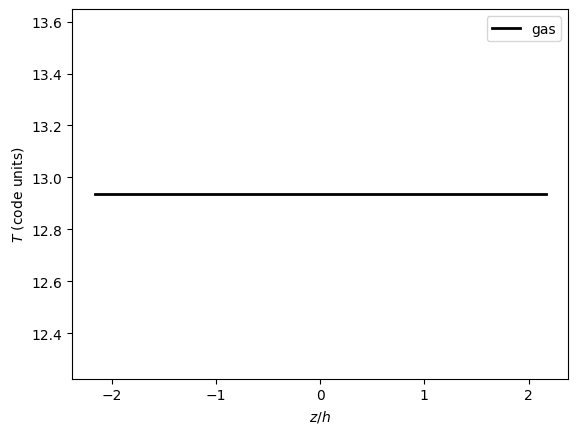

In [25]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 1.4
cg = 1.0 / (gamma - 1.0)
cd = 0.088 * cg

folder = "vsi_slowrad"

r_face = np.loadtxt("/Users/nadine/Downloads/fargo3d/outputs/" + folder + "/domain_y.dat")[3:-3]
t_face = np.loadtxt("/Users/nadine/Downloads/fargo3d/outputs/" + folder + "/domain_z.dat")[3:-3]

rmed = 0.5 * (r_face[1:] + r_face[:-1])
tmed = 0.5 * (t_face[1:] + t_face[:-1])

Tcoord, Rcoord = np.meshgrid(tmed, rmed, indexing="ij")

nz = len(tmed)
ny = len(rmed)

r_mask = np.abs(Rcoord - 1.0) < 0.05
aspect = 0.06
z_h_prof = np.cos(tmed) / aspect

# --- GAS ---
e_gas = np.fromfile(f"../../outputs/" + folder + "/gasenergy0.dat").reshape(nz, ny)
rho_gas = np.fromfile(f"../../outputs/" + folder + "/gasdens0.dat").reshape(nz, ny)

temp_gas = e_gas / (rho_gas * cg) * T_scale_K

temp_prof_gas = np.array([
    np.nanmean(temp_gas[iz, r_mask[iz, :]])
    for iz in range(nz)
])

# --- DUST ---
NFLUIDS = 2
temp_profiles_dust = []

for i in range(1, NFLUIDS - 1):
    e = np.fromfile(f"../../outputs/" + folder + f"/dust{i}energy0.dat").reshape(nz, ny)
    rho = np.fromfile(f"../../outputs/" + folder + f"/dust{i}dens0.dat").reshape(nz, ny)

    temp = e / (rho * cd) * T_scale_K

    temp_prof = np.array([
        np.nanmean(temp[iz, r_mask[iz, :]])
        for iz in range(nz)
    ])

    temp_profiles_dust.append(temp_prof)

# --- PLOT ---
plt.plot(z_h_prof, temp_prof_gas, color="black", linewidth=2, label="gas")

for i, prof in enumerate(temp_profiles_dust):
    plt.plot(z_h_prof, prof, linestyle="--", label=f"dust {i+1}")

plt.xlabel(r"$z/h$")
plt.ylabel(r"$T$ (code units)")
plt.legend()
plt.show()

In [189]:
import numpy as np
import matplotlib.pyplot as plt


G_CGS = 6.674e-8
MSTAR_CGS = 1.9891e33
R0_CGS = 30.0 * 1.49597871e13
R_MU_CGS = 34447318.36

G = 1
MSTAR =1
R0 =1
R_MU = 1

gamma = 1.4
CPDG = 0.088
H0 = 0.06
R_au = 30.0
ERGS = (G / G_CGS * MSTAR / MSTAR_CGS / R0 * R0_CGS) * (MSTAR / MSTAR_CGS)
KBOLTZ = (
    1.38064852e-16
    * ERGS
    / ((G * MSTAR / R0 / R_MU) / (G_CGS * MSTAR_CGS / R0_CGS / R_MU_CGS))
)
MH = 2.4 * 1.6726219e-24 * MSTAR / MSTAR_CGS

print(KBOLTZ/MH)
STEFANK = (
    5.6705e-5
    * (R_MU / R_MU_CGS) ** 4
    * (G / G_CGS) ** (-2.5)
    * (MSTAR / MSTAR_CGS) ** (-1.5)
    * (R0 / R0_CGS) ** (-0.5)
)
C0 = 2.99792458e10 * np.sqrt(G / G_CGS * MSTAR / MSTAR_CGS / R0 * R0_CGS)
PLANCK = 6.62607015e-27 * ERGS / np.sqrt(
    G / G_CGS * MSTAR / MSTAR_CGS / (R0 / R0_CGS) ** 3
)


# Grain: invparticlesize in thermalaccomodation_coeff.c; optional 1/a_code
a_code = 1e-4
invparticlesize = 1.0 / a_code

# Solid density [code units], same convention as 1.67/(MSTAR/R0**3)
rhosolid = 1.67 / (MSTAR / R0**3)


def plot_rates(folder, label, n):
    cvgas = R_MU / (gamma - 1.0)
    cvdust = CPDG * cvgas

    rmin = np.loadtxt(folder + "/domain_y.dat")[3:-3]
    tmin = np.loadtxt(folder + "/domain_z.dat")[3:-3]
    rmed = 0.5 * (rmin[1:] + rmin[:-1])
    tmed = 0.5 * (tmin[1:] + tmin[:-1])
    Rcoord, Tcoord = np.meshgrid(rmed, tmed)

    nz, ny = len(tmed), len(rmed)

    rhogas = np.fromfile(folder + f"/gasdens{n:d}.dat").reshape(nz, ny)
    rhodust = np.fromfile(folder + f"/dust1dens{n:d}.dat").reshape(nz, ny)
    egas = np.fromfile(folder + f"/gasenergy{n:d}.dat").reshape(nz, ny)
    edust = np.fromfile(folder + f"/dust1energy{n:d}.dat").reshape(nz, ny)

    tempgas =  egas / (rhogas * cvgas)
    tempdust = edust / (rhodust * cvdust)
    alpha = (
        0.75
        * (KBOLTZ / MH) ** 1.5
        * np.sqrt(tempgas)
        * rhogas
        * invparticlesize
        / (rhosolid * cvdust)
    )

    qlocal = 8.0 * np.pi * KBOLTZ * tempdust / invparticlesize / PLANCK / C0
    beta = np.empty_like(tempdust)
    hi = qlocal >= 1.0
    beta[hi] = (
        12.0
        * invparticlesize
        / (rhosolid * cvdust)
        * STEFANK
        * tempdust[hi] ** 3.0
    )
    lo = ~hi
    beta[lo] = (
        np.pi
        * 120.0
        * STEFANK
        * KBOLTZ
        / (PLANCK * C0 * rhosolid * cvdust)
        * tempdust[lo] ** 4.0
    )

    x = R_au * Rcoord * np.sin(Tcoord)
    z_over_h = np.cos(Tcoord) / H0
    panel1 = 1.0 / (alpha * 0.01)
    panel2 = (alpha + beta) / (alpha * 0.01 * beta )

    fig = plt.figure(figsize=(12, 4))
    ax = fig.add_subplot(111)
    # ax2 = fig.add_subplot(212)
    surf1 = ax.pcolormesh(x, z_over_h, panel1, cmap="RdBu_r", shading="auto", norm = matplotlib.colors.LogNorm())
    # surf2 = ax2.pcolormesh(x, z_over_h, panel2, cmap="RdBu_r", shading="auto")

    # for ax in (ax1):
    ax.set_xlabel("r (AU)")
    ax.set_ylabel("z/H")
    ax.set_xlim(0.6 * R_au, 1.6 * R_au)
    ax.set_xscale("log")

    ax1.set_title(label)
    fig.colorbar(surf1, ax=ax, label="tcool")
    # fig.colorbar(surf2, ax=ax2, label=r"$(\alpha+\beta)/(0.01\,\alpha\,\beta)$")
    fig.tight_layout()
    plt.show()



0.9984324611310521


In [198]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical reference scales (CGS-style anchors for fondam formulas) ---
G_CGS = 6.674e-8
MSTAR_CGS = 1.9891e33
R0_CGS = 30.0 * 1.49597871e13
R_MU_CGS = 34447318.36

# --- Dimensionless simulation units ---
G = 1.0
MSTAR = 1.0
R0 = 1.0
R_MU = 1.0

gamma = 1.4
CPDG = 0.088
H0 = 0.06
R_au = 30.0

ERGS = (G / G_CGS * MSTAR / MSTAR_CGS / R0 * R0_CGS) * (MSTAR / MSTAR_CGS)
KBOLTZ = (
    1.38064852e-16
    * ERGS
    / ((G * MSTAR / R0 / R_MU) / (G_CGS * MSTAR_CGS / R0_CGS / R_MU_CGS))
)
MH = 2.4 * 1.6726219e-24 * MSTAR / MSTAR_CGS

STEFANK = (
    5.6705e-5
    * (R_MU / R_MU_CGS) ** 4
    * (G / G_CGS) ** (-2.5)
    * (MSTAR / MSTAR_CGS) ** (-1.5)
    * (R0 / R0_CGS) ** (-0.5)
)
C0 = 2.99792458e10 * np.sqrt(G / G_CGS * MSTAR / MSTAR_CGS / R0 * R0_CGS)
PLANCK = 6.62607015e-27 * ERGS / np.sqrt(
    G / G_CGS * MSTAR / MSTAR_CGS / (R0 / R0_CGS) ** 3
)

a_code = 100*1e-4/R0_CGS
invparticlesize = 1.0 / a_code

rhosolid = 1.67 / (MSTAR_cgs / R0_cgs**3)

cvgas = R_MU / (gamma - 1.0)
cvdust = CPDG * cvgas

# Code temperature -> Kelvin; gas density code -> g/cm^3 (mass MSTAR_CGS / length R0_CGS^3)
T_SCALE_K = G_CGS * MSTAR_CGS / (R0_CGS * R_MU_CGS)


def plot_rates(folder, label, n):
    rmin = np.loadtxt(folder + "/domain_y.dat")[3:-3]
    tmin = np.loadtxt(folder + "/domain_z.dat")[3:-3]
    rmed = 0.5 * (rmin[1:] + rmin[:-1])
    tmed = 0.5 * (tmin[1:] + tmin[:-1])
    Rcoord, Tcoord = np.meshgrid(rmed, tmed)

    nz, ny = len(tmed), len(rmed)

    rhogas = np.fromfile(folder + f"/gasdens{n:d}.dat").reshape(nz, ny)
    rhodust = np.fromfile(folder + f"/dust1dens{n:d}.dat").reshape(nz, ny)
    egas = np.fromfile(folder + f"/gasenergy{n:d}.dat").reshape(nz, ny)/2
    edust = np.fromfile(folder + f"/dust1energy{n:d}.dat").reshape(nz, ny)/2

    tempgas = egas / (rhogas * cvgas)
    tempdust = edust / (rhodust * cvdust)

    alpha = (
        0.75
        * (KBOLTZ / MH) ** 1.5
        * np.sqrt(tempgas)
        * rhogas
        * invparticlesize
        / (rhosolid * cvdust)
    )

    qlocal = 8.0 * np.pi * KBOLTZ * tempdust / invparticlesize / PLANCK / C0
    beta = np.empty_like(tempdust)
    hi = qlocal >= 1.0
    beta[hi] = (
        12.0
        * invparticlesize
        / (rhosolid * cvdust)
        * STEFANK
        * tempdust[hi] ** 3.0
    )
    lo = ~hi
    beta[lo] = (
        np.pi
        * 120.0
        * STEFANK
        * KBOLTZ
        / (PLANCK * C0 * rhosolid * cvdust)
        * tempdust[lo] ** 4.0
    )

    x = R_au * Rcoord * np.sin(Tcoord)
    z_over_h = np.cos(Tcoord) / H0
    panel1 = 1.0 / (alpha * 0.01)
    panel2 = (alpha + beta) / (alpha * 0.01 * beta )
    ratio = panel2 / panel1

    T_gas_K = tempgas * T_SCALE_K
    rho_gas_cgs = rhogas * MSTAR_CGS / R0_CGS**3

    fig = plt.figure(figsize=(12, 10))
    axes = [
        fig.add_subplot(311),
        fig.add_subplot(312),
        fig.add_subplot(313),
    ]
    fields = [
        (T_gas_K, r"$T_{\rm gas}$ [K]", "viridis"),
        (rho_gas_cgs, r"$\rho_{\rm gas}$ [g/cm$^3$]", "magma"),
        (panel2, "tcool", "RdBu_r"),
    ]

    for ax, (fld, clabel, cmap) in zip(axes, fields):
        surf = ax.pcolormesh(x, z_over_h, fld, cmap=cmap, shading="auto", norm = mcolors.LogNorm())
        ax.set_ylabel("z/H")
        ax.set_xlim(0.6 * R_au, 1.6 * R_au)
        ax.set_xscale("log")
        fig.colorbar(surf, ax=ax, label=clabel)

    axes[0].set_title(label)
    axes[-1].set_xlabel("r (AU)")
    fig.tight_layout()
    plt.show()


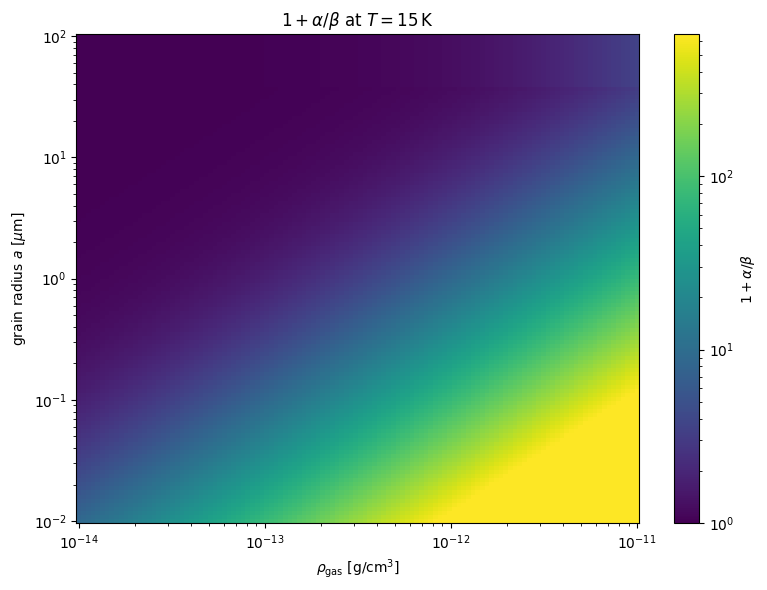

In [ ]:
"""
Parameter scan in pure CGS: same functional form as thermalaccomodation_coeff.c
(DUSTSIZE alpha + THERMALRELAXATION beta), no code units.

Grid: gas density rho_gas [g/cm^3] × grain radius a [cm], fixed T_gas = T_dust = 15 K.

Ratio plotted: 1 + alpha/beta (collision-time-weighted vs radiation channel).

Adjust rho_min/rho_max, n_a, n_rho, temperature, rho_solid as needed.
"""

import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS physical constants ---
KB = 1.380649e-16  # erg / K
MH = 2.4 * 1.6726219e-24  # g  (mean gas particle mass scale in FARGO)
PLANCK = 6.62607015e-27  # erg s
C_LIGHT = 2.99792458e10  # cm/s
STEFAN = 5.670374419e-5  # erg / (s cm^2 K^4)

gamma = 1.4
CPDG = 0.088

# Specific gas constant R/mu [erg/(g K)] — same order as your R_MU_CGS
R_MU = 34447318.36

cpgas =  R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas

T_gas = 15.0  # K
T_dust = 15.0  # K
rho_solid = 1.67  # g/cm^3 silicate-like

# Grain radii: 1e-2 µm to 100 µm  (1 µm = 1e-4 cm)
a_cm = np.logspace(np.log10(1e-2 * 1e-4), np.log10(100 * 1e-4), 120)  # cm

# Gas density range [g/cm^3] — span typical disk-like values; edit as needed
rho_gas = np.logspace(-14, -11, 120)

RHO, A = np.meshgrid(rho_gas, a_cm, indexing="xy")
inv_particlesize = 1.0 / A  # 1 / a

# --- alpha (collisional accommodation), same structure as .c DUSTSIZE branch ---
alpha = (
    0.75
    * (KB / MH) ** 1.5
    * np.sqrt(T_gas)
    * RHO
    * inv_particlesize
    / (rho_solid * cpdust)
)

# --- beta (radiative cooling branch from qlocal) ---
qlocal = 8.0 * np.pi * KB * T_dust / inv_particlesize / PLANCK / C_LIGHT

beta = np.empty_like(RHO)
mask_hi = qlocal >= 1.0
beta[mask_hi] = (
    12.0
    * inv_particlesize[mask_hi]
    / (rho_solid * cpdust)
    * STEFAN
    * T_dust ** 3.0
)
mask_lo = ~mask_hi
beta[mask_lo] = (
    np.pi
    * 120.0
    * STEFAN
    * KB
    / (PLANCK * C_LIGHT * rho_solid * cpdust)
    * T_dust ** 4.0
)

ratio = 1.0 + alpha /beta

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    rho_gas,
    a_cm * 1e4,  # plot radius in micrometers
    ratio,
    shading="auto",
    cmap="viridis",
    norm=mcolors.LogNorm(
        vmin=1, vmax=np.nanpercentile(ratio, 95)
    ),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\rho_{\rm gas}$ [g/cm$^3$]")
ax.set_ylabel(r"grain radius $a$ [$\mu$m]")
ax.set_title(r"$1 + \alpha/\beta$ at $T = 15\,$K")
fig.colorbar(im, ax=ax, label=r"$1+\alpha/\beta$")
fig.tight_layout()
plt.show()


In [ ]:
"""
Grain-size bins: log-spaced edges a_min … a_max (NFLUIDS edges → NFLUIDS−1 dust species).

Given a power-law index `slope` for how dust mass is distributed in grain radius between
a_min and a_max, ε_n are the mass fractions of the total dust abundance EPSILON in each
bin — same closed form as the FARGO loop, but with **grain radius edges** a_plus[], not
Stokes edges.

Then α(a), β(a) at each bin center a_n = sqrt(a_plus[n]·a_plus[n+1]) [cm].

Use ``inverse_ratio_tcools`` for (Σ ε_n α_n)/(Σ ε_n harm_n), harm = αβ/(α+β).

``plot_ratio_temperature_grainsize`` draws that ratio on a T × a_max grid at fixed ρ_gas.
"""

import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS (aligned with plot_rates.py fondam-style literals where applicable) ---
KB = 1.38064852e-16
MH = 2.4 * 1.6726219e-24
PLANCK = 6.62607015e-27
C_LIGHT = 2.99792458e10
STEFAN = 5.6705e-5

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36
cpgas = gamma * R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67

# --- dust multispecies bookkeeping (gas + NFLUIDS−1 dust bins in code; here only bins) ---
NFLUIDS = 7
EPSILON = 0.01
SLOPE = 3.5

# Grain radii [cm]: lower edge fixed, scan upper edge (distribution support)
AMIN_CM = 1e-5
AMAX_SCAN = np.logspace(np.log10(5e-5), np.log10(5e-2), 80)

# If NFLUIDS == 2: one dust bin, all EPSILON at this radius [cm]
A_SINGLE_CM = 1e-3

# defaults for ``plot_ratio_temperature_grainsize``: fixed ρ, sweep T and upper grain edge a_max
RHO_GAS_CGS = 1e-13
T_SCAN = np.logspace(np.log10(5.0), np.log10(300.0), 80)


def epsilons_from_grain_size_distribution(
    nfluids, epsilon_total, a_min, a_max, slope, a_single_cm=A_SINGLE_CM
):
    """
    Log-spaced grain-radius edges on [a_min, a_max]; ε_n from power-law mass in a (or log if slope==0).

    Matches the FARGO ε prescription with stokes_plus → a_plus (grain size, not Stokes).

    Returns
        epsilons : (n_dust,)
        a_center_cm : (n_dust,) geometric mean of adjacent edges
        a_plus : (nfluids,) bin edges, or None if nfluids==2
    """
    nfluids = int(nfluids)
    if nfluids < 2:
        raise ValueError("nfluids must be >= 2")
    if nfluids == 2:
        return np.array([epsilon_total]), np.array([float(a_single_cm)]), None

    a_plus = np.logspace(np.log10(a_min), np.log10(a_max), nfluids)
    n_dust = nfluids - 1
    epsilons = np.zeros(n_dust)
    a_center = np.zeros(n_dust)
    for n in range(n_dust):
        if slope != 0.0:
            epsilons[n] = (a_plus[n + 1] ** slope - a_plus[n] ** slope) * (
                epsilon_total / (a_max**slope - a_min**slope)
            )
        else:
            epsilons[n] = np.log(a_plus[n + 1] / a_plus[n]) * (
                epsilon_total / np.log(a_max / a_min)
            )
        a_center[n] = np.sqrt(a_plus[n] * a_plus[n + 1])
    return epsilons, a_center, a_plus


def inverse_ratio_tcools(T_k, rho_gas, a_min, a_max, slope):
    """(Σ ε α) / (Σ ε harm) with harm = αβ/(α+β); grain bins only."""
    eps, a_cm, _ = epsilons_from_grain_size_distribution(
        NFLUIDS, EPSILON, a_min, a_max, slope
    )
    num_a = 0.0
    den_h = 0.0
    for n in range(len(eps)):
        inv = 1.0 / a_cm[n]
        al = (
            0.75
            * (KB / MH) ** 1.5
            * np.sqrt(T_k)
            * rho_gas
            * inv
            / (rho_solid * cpdust)
        )
        ql = 8.0 * np.pi * KB * T_k / inv / PLANCK / C_LIGHT
        if ql >= 1.0:
            be = (
                12.0
                * inv
                / (rho_solid * cpdust)
                * STEFAN
                * T_k**3.0
            )
        else:
            be = (
                np.pi
                * 120.0
                * STEFAN
                * KB
                / (PLANCK * C_LIGHT * rho_solid * cpdust)
                * T_k**4.0
            )
        harm = al * be / (al + be)
        w = eps[n]
        num_a += w * al
        den_h += w * harm
    return num_a / den_h


def plot_ratio_temperature_grainsize(
    rho_gas=RHO_GAS_CGS,
    T_scan=T_SCAN,
    amax_scan=AMAX_SCAN,
    amin_cm=AMIN_CM,
    slope=SLOPE,
    figsize=(8, 6),
    show=True,
):
    """
    Colour map of (Σ ε α)/(Σ ε harm) vs temperature [K] (x) and distribution upper radius
    a_max [cm] (y), at fixed gas density.

    By default calls ``plt.show()`` so a window appears when you run a script. In a
    notebook you can use ``show=False`` if the figure is shown automatically.
    """
    ratio_grid = np.empty((len(T_scan), len(amax_scan)))
    for i, T_k in enumerate(T_scan):
        for j, a_max in enumerate(amax_scan):
            ratio_grid[i, j] = inverse_ratio_tcools(T_k, rho_gas, amin_cm, a_max, slope)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.pcolormesh(
        T_scan,
        amax_scan,
        ratio_grid.T,
        shading="auto",
        cmap="viridis",
        norm=mcolors.LogNorm(
            vmin=np.nanpercentile(ratio_grid, 5),
            vmax=np.nanpercentile(ratio_grid, 95),
        ),
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$T$ [K]")
    ax.set_ylabel(r"$a_{\max}$ [cm] (upper grain-radius edge)")
    ax.set_title(
        r"$\dfrac{\sum_n \epsilon_n \alpha_n}{\sum_n \epsilon_n \alpha_n\beta_n/(\alpha_n+\beta_n)}$"
        r"  ($\rho_{\rm gas}=%.0e$ g cm$^{-3}$, $a_{\min}=%.0e$ cm)"
        % (rho_gas, amin_cm)
    )
    fig.colorbar(im, ax=ax, label=r"$(\sum \epsilon\alpha)/(\sum \epsilon\,{\rm harm})$")
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax


# --- Draine-style radiated power: ∫ Q_abs(λ,a) π B_λ(T) dλ over a sphere (illustrative) ---

# Refractive index ~ graphitic (illustrative; Draine & Lee use tabulated optical data)
_M_DEFAULT = 1.8 + 0.05j
# Wien λ [cm] for B_λ maximum: λ_peak T ≈ 0.2898 cm K (wavelength form)
_WIEN_LAMBDA_T_CM_K = 0.2898


def planck_B_lambda_cm(T_k, lam_cm):
    """
    Planck spectral radiance B_λ [erg s⁻¹ cm⁻² sr⁻¹ (cm⁻¹) of λ interval] for λ in cm.
    """
    lam_cm = np.maximum(np.asarray(lam_cm, dtype=float), 1e-40)
    T_k = float(T_k)
    u = PLANCK * C_LIGHT / (lam_cm * KB * T_k)
    u = np.minimum(u, 700.0)  # avoid overflow in expm1 for very small λ
    return 2.0 * PLANCK * C_LIGHT**2 / lam_cm**5 / np.expm1(u)


def Q_abs_rayleigh_dipole(lam_cm, a_cm, m=_M_DEFAULT):
    """
    Small-sphere electric-dipole absorption efficiency (x = 2πa/λ ≪ 1),
    Q_abs ≈ 12 x Im[(m²−1)/(m²+2)] (Bohren & Huffman); clipped to [0, 2].
    """
    lam_cm = np.asarray(lam_cm, dtype=float)
    x = 2.0 * np.pi * a_cm / np.maximum(lam_cm, 1e-40)
    m2 = m * m
    im = np.imag((m2 - 1.0) / (m2 + 2.0))
    q = 12.0 * x * np.maximum(im, 0.0)
    return np.clip(q, 0.0, 2.0)


def radiated_power_cgs_integrated(
    T_k, a_cm, m=_M_DEFAULT, n_lambda=3000, lam_min_cm=1e-8, lam_max_cm=1.0
):
    """
    Emitted power [erg/s] for an isothermal sphere: P = 4πa² ∫ Q_abs π B_λ dλ
    (same structure as in Draine, with explicit Q_abs(λ)).
    """
    lam = np.logspace(np.log10(lam_min_cm), np.log10(lam_max_cm), int(n_lambda))
    q = Q_abs_rayleigh_dipole(lam, a_cm, m)
    b = planck_B_lambda_cm(T_k, lam)
    integrand = q * np.pi * b
    f_lambda = np.trapz(integrand, lam)
    return 4.0 * np.pi * a_cm**2 * f_lambda


def radiated_power_peak_rectangle(T_k, a_cm, m=_M_DEFAULT):
    """
    Crude 'peak wavelength' estimate: λ_peak from Wien (maximum of B_λ), then
    P ≈ 4πa² π B_λ(λ_peak) Q_abs(λ_peak) λ_peak (rectangle of width ~ λ_peak).

    Pedagogical only — not a substitute for ∫ Q_abs π B_λ dλ.
    """
    lam_peak = _WIEN_LAMBDA_T_CM_K / float(T_k)
    qpk = float(Q_abs_rayleigh_dipole(lam_peak, a_cm, m))
    bpk = float(planck_B_lambda_cm(T_k, lam_peak))
    return 4.0 * np.pi * a_cm**2 * np.pi * bpk * qpk * lam_peak


def plot_emission_integral_vs_peak_assumption(
    T_scan=None,
    a_cm=1e-4,
    m=_M_DEFAULT,
    figsize=(7, 7),
    show=True,
):
    """
    Compare **full Draine-style integral** ``radiated_power_cgs_integrated`` to the
    **single-Wien-peak rectangle** ``radiated_power_peak_rectangle``.

    Scatter: x = peak approximation [erg/s], y = integrated power [erg/s]; colour = T.
    A 1:1 line shows where they would agree.

    Parameters
    ----------
    T_scan : array-like, optional
        Temperatures [K]; default logspace(5, 300, 60).
    a_cm : float
        Grain radius [cm].
    m : complex
        Complex refractive index for ``Q_abs`` (illustrative).
    """
    if T_scan is None:
        T_scan = np.logspace(np.log10(5.0), np.log10(300.0), 60)

    p_int = np.array([radiated_power_cgs_integrated(T, a_cm, m=m) for T in T_scan])
    p_peak = np.array([radiated_power_peak_rectangle(T, a_cm, m=m) for T in T_scan])

    fig, ax = plt.subplots(figsize=figsize)
    lim_lo = min(np.nanmin(p_peak), np.nanmin(p_int)) * 0.5
    lim_hi = max(np.nanmax(p_peak), np.nanmax(p_int)) * 2.0
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], ls="--", c="0.5", lw=1.0, label="1:1")
    sc = ax.scatter(p_peak, p_int, c=T_scan, cmap="viridis", s=35, edgecolors="none")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Peak-$\lambda$ rectangle power [erg s$^{-1}$]")
    ax.set_ylabel(r"Integrated $\int Q_{\mathrm{abs}}\,\pi B_\lambda\,\mathrm{d}\lambda$ power [erg s$^{-1}$]")
    ax.set_title(r"$a=%.2e$ cm, $m=%.2f+%.2fi$" % (a_cm, m.real, m.imag))
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(r"$T$ [K]")
    ax.legend(loc="upper left")
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax, {"T_scan": T_scan, "p_integrated": p_int, "p_peak_approx": p_peak}


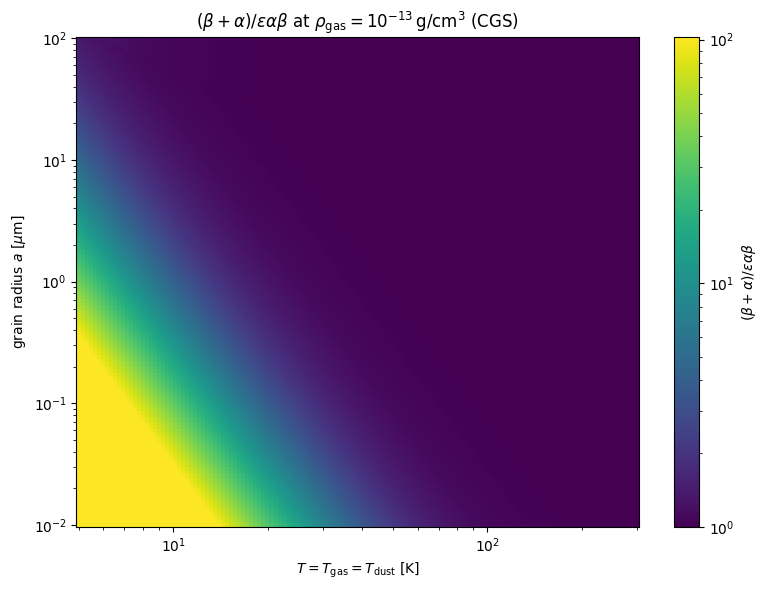

In [ ]:

import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS physical constants ---
KB = 1.380649e-16  # erg / K
MH = 2.4 * 1.6726219e-24  # g
PLANCK = 6.62607015e-27  # erg s
C_LIGHT = 2.99792458e10  # cm/s
STEFAN = 5.670374419e-5  # erg / (s cm^2 K^4)

gamma = 1.4
CPDG = 0.088

R_MU = 34447318.36  # erg/(g K)

cpgas = gamma * R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas

rho_gas = 1e-13  # g/cm^3 (fixed)
rho_solid = 1.67  # g/cm^3

# Temperature [K] — gas and dust assumed equal at each grid point
T_K = np.logspace(np.log10(5.0), np.log10(300.0), 140)

# Grain radii: 0.01 µm to 100 µm
a_cm = np.logspace(np.log10(1e-2 * 1e-4), np.log10(100 * 1e-4), 140)

TT, A = np.meshgrid(T_K, a_cm, indexing="xy")
inv_particlesize = 1.0 / A

# --- alpha ---
alpha = (
    0.75
    * (KB / MH) ** 1.5
    * np.sqrt(TT)
    * rho_gas
    * inv_particlesize
    / (rho_solid * cpdust)
)

# --- beta ---
qlocal = 8.0 * np.pi * KB * TT / inv_particlesize / PLANCK / C_LIGHT

beta = np.empty_like(TT)
mask_hi = qlocal >= 1.0
beta[mask_hi] = (
    12.0
    * inv_particlesize[mask_hi]
    / (rho_solid * cpdust)
    * STEFAN
    * TT[mask_hi] ** 3.0
)
mask_lo = ~mask_hi
beta[mask_lo] = (
    np.pi
    * 120.0
    * STEFAN
    * KB
    / (PLANCK * C_LIGHT * rho_solid * cpdust)
    * TT[mask_lo] ** 4.0
)

ratio = 1.0 + alpha / np.maximum(beta, 1e-300)
# rate = (beta + alpha) / (np.maximum(beta, 1e-300)
# )
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    T_K,
    A * 1e4,
    ratio,
    shading="auto",
    cmap="viridis",
    norm=mcolors.LogNorm(
        1,
        vmax=np.nanpercentile(ratio, 95),
    ),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$T = T_{\rm gas} = T_{\rm dust}$ [K]")
ax.set_ylabel(r"grain radius $a$ [$\mu$m]")
ax.set_title(r"$1+\alpha/\beta$ at $\rho_{\rm gas}=10^{-13}\,$g/cm$^3$ (CGS)")
fig.colorbar(im, ax=ax, label=r"$1+\alpha/\beta$")
fig.tight_layout()
plt.show()


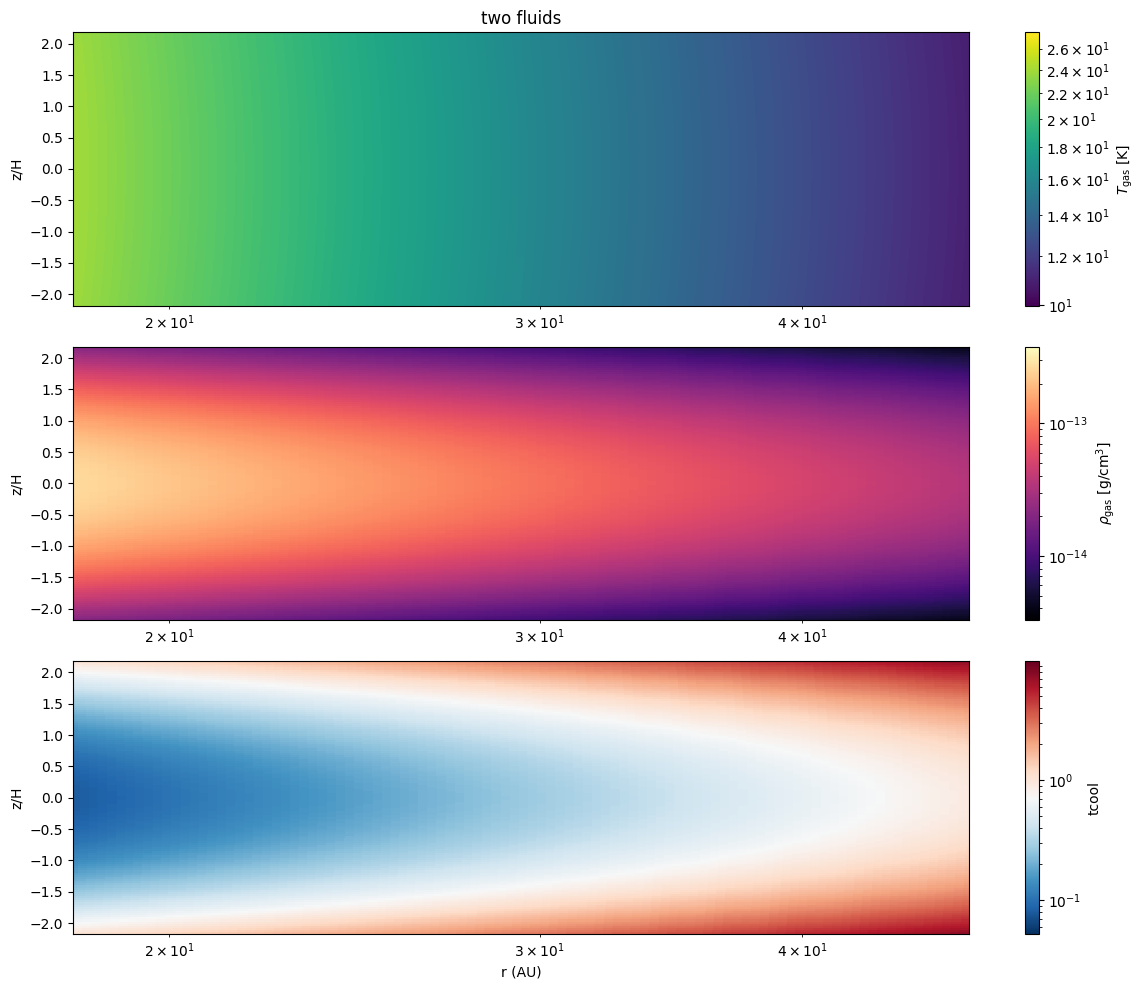

In [199]:
plot_rates("../../outputs/vsi_sametemp", "two fluids", 100)

In [ ]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS ---
KB = 1.380649e-16
MH = 2.4 * 1.6726219e-24
PLANCK = 6.62607015e-27
C_LIGHT = 2.99792458e10
STEFAN = 5.670374419e-5

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36
cpgas = gamma * R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67

# --- dust multispecies bookkeeping (gas + NFLUIDS−1 dust bins in code; here only bins) ---
NFLUIDS = 6
EPSILON = 0.01
SLOPE = 3.5

# Grain radii [cm]: lower edge fixed, scan upper edge (distribution support)
AMIN_CM = 1e-5
AMAX_SCAN = np.logspace(np.log10(2e-5), np.log10(1000 * 1e-4), 120)

# If NFLUIDS == 2: one dust bin, all EPSILON at this radius [cm]
A_SINGLE_CM = 100 * 1e-4

# defaults for ``plot_ratio_density_grainsize``: scan ρ and upper grain edge a_max at fixed T
T_FIXED_K = 15.0
RHO_SCAN = np.logspace(np.log10(1e-14), np.log10(1e-11), 120)

def inverse_ratio_tcools(T_k, rho_gas, a_min, a_max, slope):
    """(Σ ε α) / (Σ ε harm) with harm = αβ/(α+β); grain bins only."""
    eps, a_cm, _ = epsilons_from_grain_size_distribution(
        NFLUIDS, EPSILON, a_min, a_max, slope
    )
    num_a = 0.0
    den_h = 0.0
    for n in range(len(eps)):
        inv = 1.0 / a_cm[n]
        al = (
            0.75
            * (KB / MH) ** 1.5
            * np.sqrt(T_k)
            * rho_gas
            * inv
            / (rho_solid * cpdust)
        )
        ql = 8.0 * np.pi * KB * T_k / inv / PLANCK / C_LIGHT
        if ql >= 1.0:
            be = (
                12.0
                * inv
                / (rho_solid * cpdust)
                * STEFAN
                * T_k**3.0
            )
        else:
            be = (
                np.pi
                * 120.0
                * STEFAN
                * KB
                / (PLANCK * C_LIGHT * rho_solid * cpdust)
                * T_k**4.0
            )
        harm = al * be / (al + be)
        w = eps[n]
        num_a += w * al
        den_h += w * harm
    return num_a / den_h


def plot_ratio_density_grainsize(
    T_k=T_FIXED_K,
    rho_scan=RHO_SCAN,
    amax_scan=AMAX_SCAN,
    amin_cm=AMIN_CM,
    slope=SLOPE,
    figsize=(8, 6),
    show=True,
):
    ratio_grid = np.empty((len(rho_scan), len(amax_scan)))
    for i, rho in enumerate(rho_scan):
        for j, a_max in enumerate(amax_scan):
            ratio_grid[i, j] = inverse_ratio_tcools(T_k, rho, amin_cm, a_max, slope)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.pcolormesh(
        rho_scan,
        1e4 * amax_scan,
        ratio_grid.T,
        shading="auto",
        cmap="viridis",
        norm=mcolors.LogNorm(
            vmin=1,
            vmax=100,
        ),
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\rho_{\rm gas}$ [g cm$^{-3}$]")
    ax.set_ylabel(r"$a_{\max} [\mu m]$ ")
    ax.set_title(
        r"$\dfrac{\sum_n \epsilon_n \alpha_n}{\sum_n \epsilon_n \alpha_n\beta_n/(\alpha_n+\beta_n)}$"
        r"  ($T=%.1f$ K, $a_{\min}=%.0e \mu m$)" % (T_k, amin_cm*1e4)
    )
    fig.colorbar(im, ax=ax, label= r"$\dfrac{\sum_n \epsilon_n \alpha_n}{\sum_n \epsilon_n \alpha_n\beta_n/(\alpha_n+\beta_n)}$")
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax


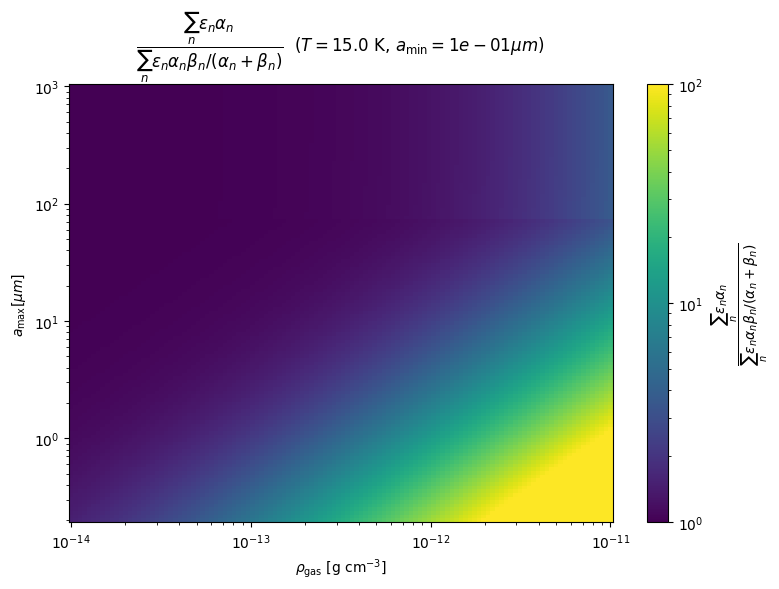

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': '$\\dfrac{\\sum_n \\epsilon_n \\alpha_n}{\\sum_n \\epsilon_n \\alpha_n\\beta_n/(\\alpha_n+\\beta_n)}$  ($T=15.0$ K, $a_{\\min}=1e-01 \\mu m$)'}, xlabel='$\\rho_{\\rm gas}$ [g cm$^{-3}$]', ylabel='$a_{\\max} [\\mu m]$ '>)

In [36]:
plot_ratio_density_grainsize()

In [173]:
"""
Grain-size bins: log-spaced edges a_min … a_max (NFLUIDS edges → NFLUIDS−1 dust species).

Given a power-law index `slope` for how dust mass is distributed in grain radius between
a_min and a_max, ε_n are the mass fractions of the total dust abundance EPSILON in each
bin — same closed form as the FARGO loop, but with **grain radius edges** a_plus[], not
Stokes edges.

Then α(a), β(a) at each bin center a_n = sqrt(a_plus[n]·a_plus[n+1]) [cm].

Use ``inverse_ratio_tcools`` for (Σ ε_n α_n)/(Σ ε_n harm_n), harm = αβ/(α+β).

``plot_ratio_temperature_grainsize`` draws that ratio on a T × a_max grid at fixed ρ_gas.
"""

import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS (aligned with plot_rates.py fondam-style literals where applicable) ---
KB = 1.38064852e-16
MH = 2.4 * 1.6726219e-24
PLANCK = 6.62607015e-27
C_LIGHT = 2.99792458e10
STEFAN = 5.6705e-5

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36
cpgas = gamma * R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67

# --- dust multispecies bookkeeping (gas + NFLUIDS−1 dust bins in code; here only bins) ---
NFLUIDS = 7
EPSILON = 0.01
SLOPE = 3.5

# Grain radii [cm]: lower edge fixed, scan upper edge (distribution support)
AMIN_CM = 1e-5
AMAX_SCAN = np.logspace(np.log10(5e-5), np.log10(5e-2), 80)

# If NFLUIDS == 2: one dust bin, all EPSILON at this radius [cm]
A_SINGLE_CM = 1e-3

# defaults for ``plot_ratio_temperature_grainsize``: fixed ρ, sweep T and upper grain edge a_max
RHO_GAS_CGS = 1e-13
T_SCAN = np.logspace(np.log10(5.0), np.log10(300.0), 80)


def epsilons_from_grain_size_distribution(
    nfluids, epsilon_total, a_min, a_max, slope, a_single_cm=A_SINGLE_CM
):
    """
    Log-spaced grain-radius edges on [a_min, a_max]; ε_n from power-law mass in a (or log if slope==0).

    Matches the FARGO ε prescription with stokes_plus → a_plus (grain size, not Stokes).

    Returns
        epsilons : (n_dust,)
        a_center_cm : (n_dust,) geometric mean of adjacent edges
        a_plus : (nfluids,) bin edges, or None if nfluids==2
    """
    nfluids = int(nfluids)
    if nfluids < 2:
        raise ValueError("nfluids must be >= 2")
    if nfluids == 2:
        return np.array([epsilon_total]), np.array([float(a_single_cm)]), None

    a_plus = np.logspace(np.log10(a_min), np.log10(a_max), nfluids)
    n_dust = nfluids - 1
    epsilons = np.zeros(n_dust)
    a_center = np.zeros(n_dust)
    for n in range(n_dust):
        if slope != 0.0:
            epsilons[n] = (a_plus[n + 1] ** slope - a_plus[n] ** slope) * (
                epsilon_total / (a_max**slope - a_min**slope)
            )
        else:
            epsilons[n] = np.log(a_plus[n + 1] / a_plus[n]) * (
                epsilon_total / np.log(a_max / a_min)
            )
        a_center[n] = np.sqrt(a_plus[n] * a_plus[n + 1])
    return epsilons, a_center, a_plus


def inverse_ratio_tcools(T_k, rho_gas, a_min, a_max, slope):
    """(Σ ε α) / (Σ ε harm) with harm = αβ/(α+β); grain bins only."""
    eps, a_cm, _ = epsilons_from_grain_size_distribution(
        NFLUIDS, EPSILON, a_min, a_max, slope
    )
    num_a = 0.0
    den_h = 0.0
    for n in range(len(eps)):
        inv = 1.0 / a_cm[n]
        al = (
            0.75
            * (KB / MH) ** 1.5
            * np.sqrt(T_k)
            * rho_gas
            * inv
            / (rho_solid * cpdust)
        )
        ql = 8.0 * np.pi * KB * T_k / inv / PLANCK / C_LIGHT
        if ql >= 1.0:
            be = (
                12.0
                * inv
                / (rho_solid * cpdust)
                * STEFAN
                * T_k**3.0
            )
        else:
            be = (
                np.pi
                * 120.0
                * STEFAN
                * KB
                / (PLANCK * C_LIGHT * rho_solid * cpdust * 10)
                * T_k**4.0
            )
        harm = al * be / (al + be)
        w = eps[n]
        num_a += w * al
        den_h += w * harm
    return num_a / den_h


def plot_ratio_temperature_grainsize(
    rho_gas=RHO_GAS_CGS,
    T_scan=T_SCAN,
    amax_scan=AMAX_SCAN,
    amin_cm=AMIN_CM,
    slope=SLOPE,
    figsize=(8, 6),
    show=True,
):
    """
    Colour map of (Σ ε α)/(Σ ε harm) vs temperature [K] (x) and distribution upper radius
    a_max [cm] (y), at fixed gas density.

    By default calls ``plt.show()`` so a window appears when you run a script. In a
    notebook you can use ``show=False`` if the figure is shown automatically.
    """
    ratio_grid = np.empty((len(T_scan), len(amax_scan)))
    for i, T_k in enumerate(T_scan):
        for j, a_max in enumerate(amax_scan):
            ratio_grid[i, j] = inverse_ratio_tcools(T_k, rho_gas, amin_cm, a_max, slope)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.pcolormesh(
        T_scan,
        amax_scan,
        ratio_grid.T,
        shading="auto",
        cmap="viridis",
        norm=mcolors.LogNorm(
            vmin=1,
            vmax=100,
        ),
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$T$ [K]")
    ax.set_ylabel(r"$a_{\max}$ [cm] (upper grain-radius edge)")
    ax.set_title(
        r"$\dfrac{\sum_n \epsilon_n \alpha_n}{\sum_n \epsilon_n \alpha_n\beta_n/(\alpha_n+\beta_n)}$"
        r"  ($\rho_{\rm gas}=%.0e$ g cm$^{-3}$, $a_{\min}=%.0e$ cm)"
        % (rho_gas, amin_cm)
    )
    fig.colorbar(im, ax=ax, label=r"$(\sum \epsilon\alpha)/(\sum \epsilon\,{\rm harm})$")
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax


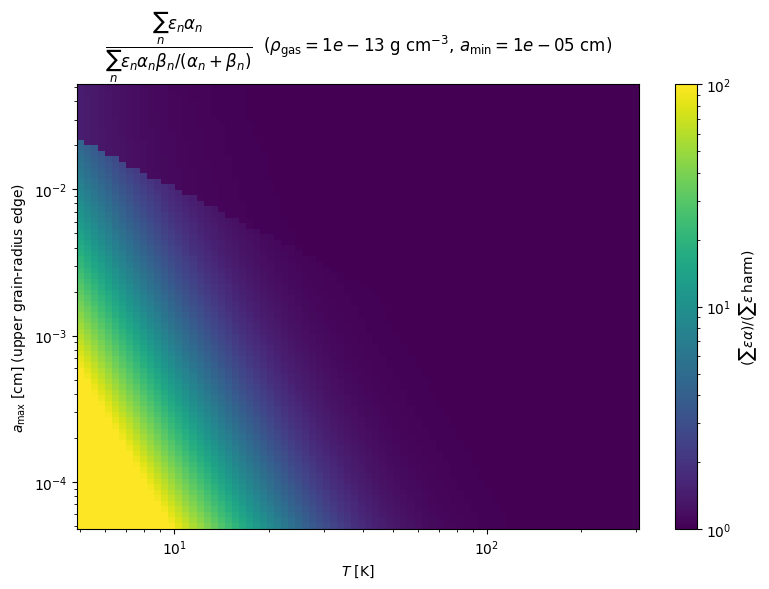

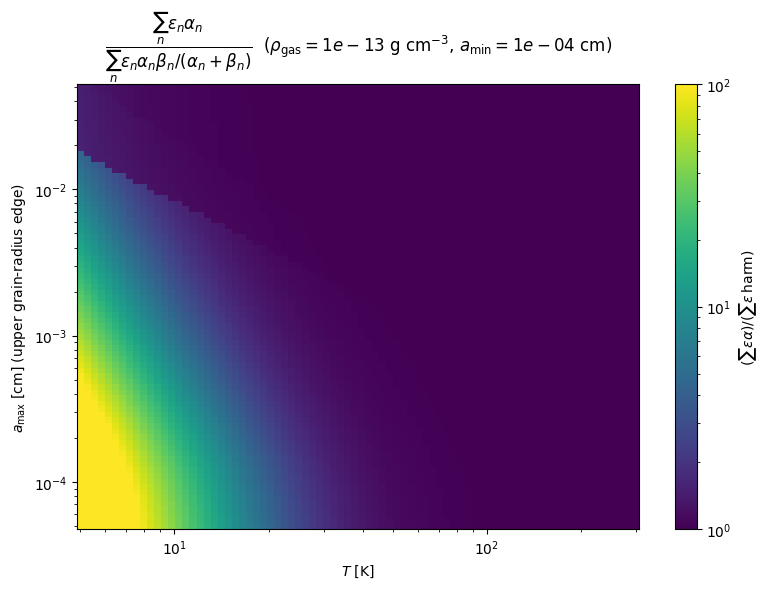

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': '$\\dfrac{\\sum_n \\epsilon_n \\alpha_n}{\\sum_n \\epsilon_n \\alpha_n\\beta_n/(\\alpha_n+\\beta_n)}$  ($\\rho_{\\rm gas}=1e-13$ g cm$^{-3}$, $a_{\\min}=1e-04$ cm)'}, xlabel='$T$ [K]', ylabel='$a_{\\max}$ [cm] (upper grain-radius edge)'>)

In [176]:
plot_ratio_temperature_grainsize(rho_gas = 1e-13, amin_cm = 1e-5)
plot_ratio_temperature_grainsize(rho_gas = 1e-13, amin_cm = 1e-4)

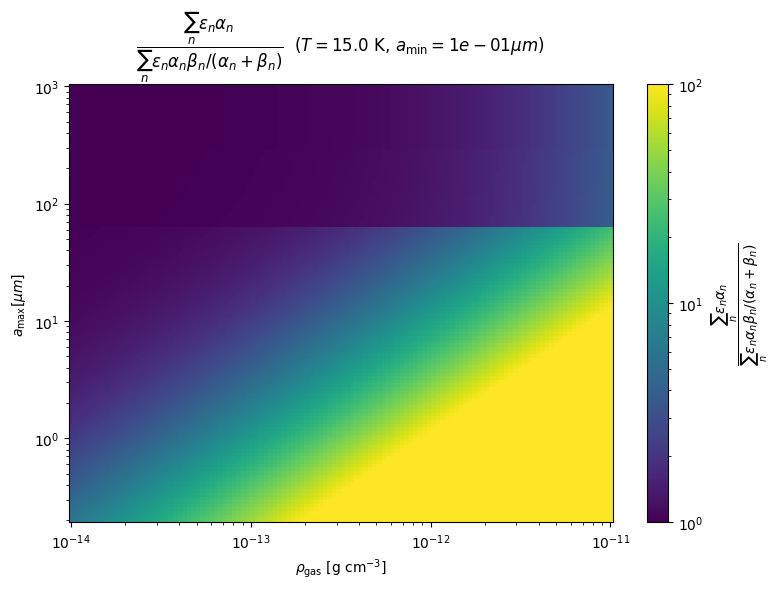

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': '$\\dfrac{\\sum_n \\epsilon_n \\alpha_n}{\\sum_n \\epsilon_n \\alpha_n\\beta_n/(\\alpha_n+\\beta_n)}$  ($T=15.0$ K, $a_{\\min}=1e-01 \\mu m$)'}, xlabel='$\\rho_{\\rm gas}$ [g cm$^{-3}$]', ylabel='$a_{\\max} [\\mu m]$ '>)

In [175]:
plot_ratio_density_grainsize()

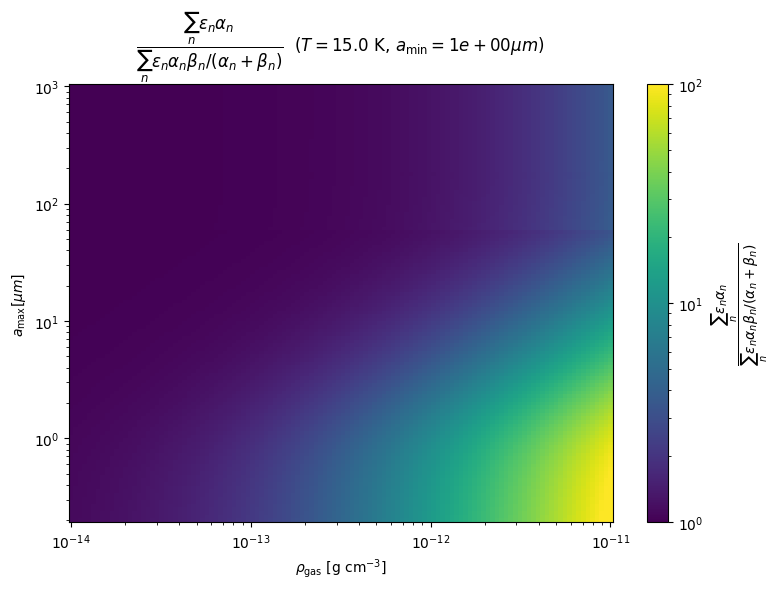

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': '$\\dfrac{\\sum_n \\epsilon_n \\alpha_n}{\\sum_n \\epsilon_n \\alpha_n\\beta_n/(\\alpha_n+\\beta_n)}$  ($T=15.0$ K, $a_{\\min}=1e+00 \\mu m$)'}, xlabel='$\\rho_{\\rm gas}$ [g cm$^{-3}$]', ylabel='$a_{\\max} [\\mu m]$ '>)

In [159]:
plot_ratio_density_grainsize(amin_cm = 1e-4)

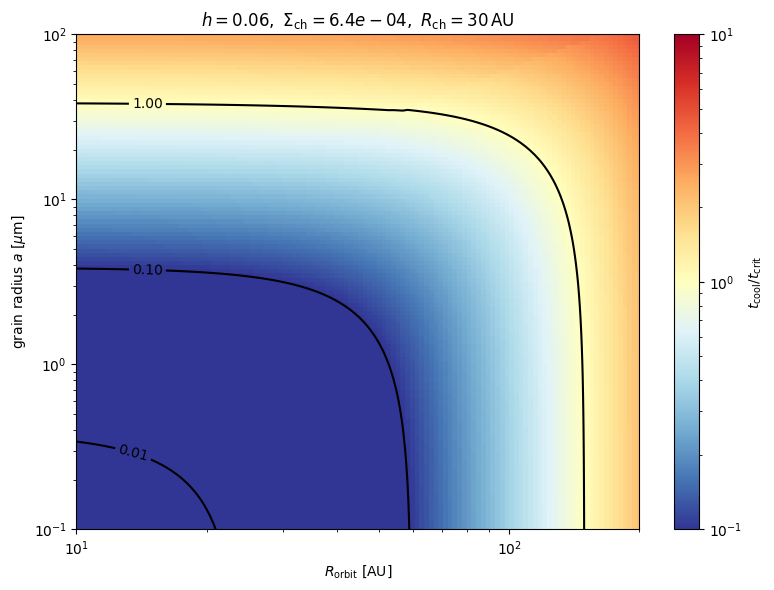

In [41]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS physical constants ---
KB = 1.380649e-16  # erg / K
MH = 2.4 * 1.6726219e-24  # g
PLANCK = 6.62607015e-27  # erg s
C_LIGHT = 2.99792458e10  # cm/s
STEFAN = 5.670374419e-5  # erg / (s cm^2 K^4)
G_CGS = 6.67430e-8  # cm^3 g^-1 s^-2
MSUN_CGS = 1.98847e33  # g
AU_CM = 1.495978707e13  # cm

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36

cpgas = R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67  # g/cm^3

# Variables
h = 0.06
M_star = 1.0 * MSUN_CGS
R_ch = 30.0 * AU_CM
Sigma_ch = 6.4*1e-4  # normalization at R_ch

# Grid of single-grain points: each (a, R) is one grain size at one orbit
a_scan_cm = np.logspace(np.log10(1e-1 * 1e-4), np.log10(100 * 1e-4), 120)
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 120)

A, R = np.meshgrid(a_scan_cm, R_scan_cm, indexing="xy")
inv_particlesize = 1.0 / A
r = R / R_ch

# rho(R) = rho_ch * r^-1, with r = R/R_ch and
# rho_ch anchored from the previous normalization at R_ch.
rho_ch = Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)
rho_gas = rho_ch / r

# T(R) = T_ch * r^-1
T_ch = h**2 * G_CGS * M_star / (R_ch * R_MU * r)
# T_ch = 150 *np.power((R_ch * r/AU_CM), -3/7)
T_gas = T_ch 
T_dust = T_gas

# Omega(R) = Omega_ch * r^-3 (requested scaling)
omega_ch = np.sqrt(G_CGS * M_star / (R_ch**3))
omega = omega_ch / (r**(3/2))
tcrit = h / ((gamma - 1.0) * omega)

alpha = (
    0.75
    * (KB / MH) ** 1.5
    * np.sqrt(T_gas)
    * rho_gas
    * inv_particlesize
    / (rho_solid * cpdust)
)

qlocal = 8.0 * np.pi * KB * T_dust / inv_particlesize / PLANCK / C_LIGHT
beta = np.empty_like(alpha)
mask_hi = qlocal >= 1.0
beta[mask_hi] = (
    12.0
    * inv_particlesize[mask_hi]
    / (rho_solid * cpdust)
    * STEFAN
    * (T_dust[mask_hi] ** 3.0)/12
)
mask_lo = ~mask_hi
beta[mask_lo] = (
    np.pi
    * 120.0
    * STEFAN
    * KB
    / (PLANCK * C_LIGHT * rho_solid * cpdust)
    * (T_dust[mask_lo] ** 4.0)/12
)
H = 0.1*h*R
eps = 0.005
tau = 3/4*0.01 * rho_gas / rho_solid * inv_particlesize *np.min(A*T_dust*1e4/600, 1) * H
ratio = ((alpha + beta) / (eps * alpha * beta)) / tcrit

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    R_scan_cm / AU_CM,
    a_scan_cm * 1e4,
    ratio.T,
    shading="auto",
    cmap="RdYlBu_r",
    norm=mcolors.LogNorm(
        vmin=0.1,
        vmax=10,
    ),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10, 200)
ax.set_ylim(0.1, 100)
c = plt.contour(R_scan_cm / AU_CM, a_scan_cm * 1e4, ratio.T, [0.01, 0.1, 1, 10, 50], colors = "black")
plt.clabel(c, inline=True, fontsize=10, fmt='%.2f')


ax.set_xlabel(r"$R_{\rm orbit}$ [AU]")
ax.set_ylabel(r"grain radius $a$ [$\mu$m]")
ax.set_title(
    r"$h=%.2f,\ \Sigma_{\rm ch}=%.1e,\ R_{\rm ch}=%.0f\,{\rm AU}$"
    % (h, Sigma_ch, R_ch / AU_CM)
)
fig.colorbar(im, ax=ax, label=r"$t_{\rm cool}/t_{\rm crit}$")
fig.tight_layout()
plt.show()


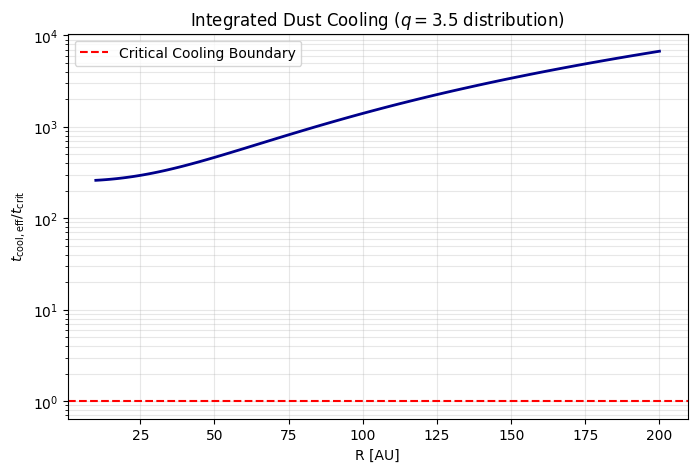

In [251]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# ... [Keep your constants KB, MH, STEFAN, etc. from above] ...

def calculate_dust_distribution(n_fluids, s_min, s_max, epsilon_total, q_slope=3.5):
    # n_fluids here represents the number of dust bins
    a_plus = np.logspace(np.log10(s_min), np.log10(s_max), n_fluids + 1)
    epsilons = np.zeros(n_fluids)
    a_center = np.zeros(n_fluids)
    slope = 4.0 - q_slope
    
    if slope != 0.0:
        norm = epsilon_total / (s_max**slope - s_min**slope)
        epsilons = (a_plus[1:]**slope - a_plus[:-1]**slope) * norm
    else:
        norm = epsilon_total / np.log(s_max / s_min)
        epsilons = np.log(a_plus[1:] / a_plus[:-1]) * norm
        
    a_center = np.sqrt(a_plus[1:] * a_plus[:-1])
    return epsilons, a_center

# --- Distribution Parameters ---
n_dust_bins = 50
eps_total = 0.01
a_min_cm = 1e-5  # 0.1 micron
a_max_cm = 1e-2  # 100 microns
q_mrn = 3.5

# Calculate weights and bin centers
eps_bins, a_bins = calculate_dust_distribution(n_dust_bins, a_min_cm, a_max_cm, eps_total, q_mrn)

# --- Orbital Grid ---
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 120)
r = R_scan_cm / R_ch

# Calculate Gas properties along R (1D arrays)
rho_gas = (Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)) / r
T_gas = (h**2 * G_CGS * M_star / (R_ch * R_MU)) / r
omega = np.sqrt(G_CGS * M_star / (R_ch**3)) / (r**1.5)
tcrit = h / ((gamma - 1.0) * omega)

# --- Compute Summation ---
# We need to sum over the grain size bins for each R
integrated_inv_tcrit = np.zeros_like(R_scan_cm)

for i, r_val in enumerate(R_scan_cm):
    # Compute alpha and beta for all grain bins at this specific R
    inv_a = 1.0 / a_bins
    
    alpha_bin = 0.75 * (KB / MH)**1.5 * np.sqrt(T_gas[i]) * rho_gas[i] * inv_a / (rho_solid * cpdust)
    
    qlocal = 8.0 * np.pi * KB * T_gas[i] / inv_a / (PLANCK * C_LIGHT)
    beta_bin = np.where(qlocal >= 1.0,
                        12.0 * inv_a / (rho_solid * cpdust) * STEFAN * (T_gas[i]**3)/12.0,
                        np.pi * 120.0 * STEFAN * KB / (PLANCK * C_LIGHT * rho_solid * cpdust) * (T_gas[i]**4)/12.0)
    
    # Calculate (alpha + beta) / (alpha * beta * epsilon_i) for each bin
    # This represents the cooling timescale contribution of bin i
    t_cool_bin = (alpha_bin + beta_bin) / (alpha_bin * beta_bin * eps_bins)
    
    # The effective cooling time of the population is the sum of these contributions
    integrated_inv_tcrit[i] = np.sum(t_cool_bin) / tcrit[i]

# --- Plotting Result ---
plt.figure(figsize=(8, 5))
plt.plot(R_scan_cm / AU_CM, integrated_inv_tcrit, lw=2, color='darkblue')
plt.axhline(1.0, color='red', ls='--', label='Critical Cooling Boundary')
plt.yscale('log')
plt.xlabel('R [AU]')
plt.ylabel(r'$t_{\rm cool, eff} / t_{\rm crit}$')
plt.title(f'Integrated Dust Cooling ($q={q_mrn}$ distribution)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

In [42]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- Setup Grid ---
n_bins = 5
q = 1
a_min_cm = 1e-5 # 0.1 micron
a_max_scan = np.logspace(np.log10(1e-5), np.log10(1e-1), 50) # scan a_max up to 1mm
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 50)
eps_total = 0.01
q_mrn = 3.5
z_height_H = gamma /2
# Result array
ratio_map = np.zeros((len(a_max_scan), len(R_scan_cm)))
L = 0.1*h*R

# --- Two-Dimensional Scan ---
for j, a_max_val in enumerate(a_max_scan):
    # Calculate the 5-bin weights for this specific a_max
    # If a_max == a_min, handle as a single bin
    if a_max_val <= a_min_cm:
        eps_bins = np.array([eps_total])
        a_bins = np.array([a_min_cm])
    else:
        eps_bins, a_bins = calculate_dust_distribution(n_bins, a_min_cm, a_max_val, eps_total, q_mrn)
    
    inv_a = 1.0 / a_bins

    for i, r_cm in enumerate(R_scan_cm):
        # Local Gas Physics at R
        r_rel = r_cm / R_ch
        rho_g = (Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)) / r_rel * np.exp(-1*(z_height_H**2)/2)
        temp_g = (h**2 * G_CGS * M_star / (R_ch * R_MU)) / np.power(r_rel, q)
        # temp_g = 150 *np.power((R_ch * r_rel/AU_CM), -3/7)
        om = np.sqrt(G_CGS * M_star / (R_ch**3)) / (r_rel**1.5)
        t_crit_local = h*q / ((gamma - 1.0) * om)
        # Q = np.minimum(a_bins*temp_g*1e4/600, 1) 
        # tau = 3/4*np.sum( eps_bins * rho_gas / rho_solid * inv_a *Q * L)
        # opacity = (1 + 3*tau**2)
        
        # Physics for the 5 bins
        alpha_bins = 0.75 * (KB / MH)**1.5 * np.sqrt(temp_g) * rho_g * inv_a / (rho_solid * cpdust)
        
        q_loc = 8.0 * np.pi * KB * temp_g / inv_a / (PLANCK * C_LIGHT)
        beta_bins = np.where(q_loc >= 1.0,
                            12.0 * inv_a / (rho_solid * cpdust) * STEFAN * (temp_g**3)/10.0,
                            np.pi * 120.0 * STEFAN * KB / (PLANCK * C_LIGHT * rho_solid * cpdust) * (temp_g**4)/10.0)
        
        # Summation: sum_i ((alpha + beta) / (alpha * beta * eps_i))
        t_cool_eff = np.sum((alpha_bins + beta_bins) / (alpha_bins * beta_bins * eps_bins))*opacity

        
        ratio_map[j, i] = t_cool_eff / t_crit_local

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 6))
X, Y = np.meshgrid(R_scan_cm / AU_CM, a_max_scan * 1e4)
im = ax.pcolormesh(X, Y, ratio_map, shading="auto", cmap="RdYlBu_r", norm=mcolors.LogNorm(vmin=0.1, vmax=10))

# Critical Contours
ax.set_xscale("log")
ax.set_yscale("log")
cs = ax.contour(X, Y, ratio_map, levels=[0.1, 1.0, 10.0], colors='black', linestyles=['solid', 'dashed'])
plt.clabel(cs, inline=True, fontsize=10)


ax.set_xlabel("Radius [AU]")
ax.set_ylabel(r"Maximum Grain Size $a_{\rm max}$ [$\mu$m]")
ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")
fig.colorbar(im, label=r"$t_{\rm cool} / t_{\rm crit}$")
plt.show()

<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\e'
/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_7790/2783981164.py:70: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")
/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_7790/2783981164.py:70: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")


NameError: name 'opacity' is not defined

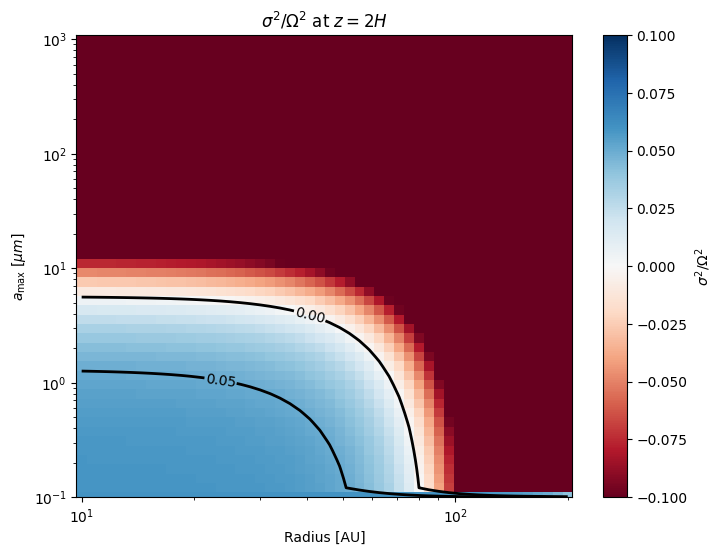

In [253]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- 1. CGS physical constants & Disk Parameters ---
KB = 1.380649e-16
MH = 2.4 * 1.6726219e-24
PLANCK = 6.62607015e-27
C_LIGHT = 2.99792458e10
STEFAN = 5.670374419e-5
G_CGS = 6.67430e-8
MSUN_CGS = 1.98847e33
AU_CM = 1.495978707e13

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36
cpgas = R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67 

# Disk Structure Constants
h = 0.06           # Aspect ratio H/R
q_index = 1      # Radial temperature gradient index
M_star = 1.0 * MSUN_CGS
R_ch = 30.0 * AU_CM
Sigma_ch = 6.4e-4 
z_height_H = 2.0   # Evaluation height for buoyancy

# --- 2. Supporting Functions ---
def calculate_dust_distribution(n_fluids, s_min, s_max, epsilon_total, q_slope=3.5):
    n_dust = n_fluids - 1
    a_plus = np.logspace(np.log10(s_min), np.log10(s_max), n_dust + 1)
    slope = 4.0 - q_slope
    
    if slope != 0.0:
        norm = epsilon_total / (s_max**slope - s_min**slope)
        epsilons = (a_plus[1:]**slope - a_plus[:-1]**slope) * norm
    else:
        norm = epsilon_total / np.log(s_max / s_min)
        epsilons = np.log(a_plus[1:] / a_plus[:-1]) * norm
        
    a_center = np.sqrt(a_plus[1:] * a_plus[:-1])
    return epsilons, a_center

# --- 3. Setup Scan Grid ---
n_bins = 5
a_min_cm = 1e-5
a_max_scan = np.logspace(np.log10(1e-5), np.log10(1e-1), 50)
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 50)
eps_total = 0.01
q_mrn = 3.5

ratio_map = np.zeros((len(a_max_scan), len(R_scan_cm)))
sigma2_map = np.zeros((len(a_max_scan), len(R_scan_cm)))

# --- 4. Two-Dimensional Physics Scan ---
for j, a_max_val in enumerate(a_max_scan):
    # Get dust weights for this a_max
    if a_max_val <= a_min_cm:
        eps_bins = np.array([eps_total])
        a_bins = np.array([a_min_cm])
    else:
        eps_bins, a_bins = calculate_dust_distribution(n_bins, a_min_cm, a_max_val, eps_total, q_mrn)
    
    inv_a = 1.0 / a_bins
    
    for i, r_cm in enumerate(R_scan_cm):
        # Local Gas Physics
        r_rel = r_cm / R_ch
        rho_g = (Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)) / r_rel * np.exp(-1*(z_height_H**2)/2)
        temp_g = (h**2 * G_CGS * M_star / (R_ch * R_MU)) / np.power(r_rel, q_index)
        om = np.sqrt(G_CGS * M_star / (R_ch**3)) / (r_rel**1.5)
        
        # Rule of thumb t_crit
        t_crit_local = h * q_index / ((gamma - 1.0) * om)
        
        # Dust Coupling (Alpha and Beta)
        alpha_bins = 0.75 * (KB / MH)**1.5 * np.sqrt(temp_g) * rho_g * inv_a / (rho_solid * cpdust)
        q_loc = 8.0 * np.pi * KB * temp_g / inv_a / (PLANCK * C_LIGHT)
        beta_bins = np.where(q_loc >= 1.0,
                            12.0 * inv_a / (rho_solid * cpdust) * STEFAN * (temp_g**3)/10.0,
                            np.pi * 120.0 * STEFAN * KB / (PLANCK * C_LIGHT * rho_solid * cpdust) * (temp_g**4)/10.0)
        
        # Effective Cooling Time (Integrated over 5 bins)
        t_cool_eff = np.sum((alpha_bins + beta_bins) / (alpha_bins * beta_bins * eps_bins))
        ratio_map[j, i] = t_cool_eff / t_crit_local
        
        # --- VSI Growth Rate Calculation ---
        # 1. Un-damped Buoyancy at z=2H
        Nz2 = (gamma - 1.0)/gamma * (om**2) * (z_height_H**2)
        
        # 2. Shear Term (Destabilizing)
        # H_loc = h * r_cm
        shear_term = np.abs(q_index) * h * (om**2)
        
        # 3. Apply Thermal Damping
        om_t = om * t_cool_eff
        Nz_eff2 = Nz2 * (om_t**2 / (1.0 + om_t**2))
        
        # 4. Resulting Growth Rate
        sigma2_map[j, i] = (shear_term - Nz_eff2) / (om**2)

# --- 5. Final Plotting (Growth Rate) ---
fig, ax = plt.subplots(figsize=(8, 6))
X, Y = np.meshgrid(R_scan_cm / AU_CM, a_max_scan * 1e4)
im = ax.pcolormesh(X, Y, sigma2_map, shading="auto", cmap="RdBu", vmin=-0.1, vmax=0.1)

# Cyan line marks the VSI Stability Boundary

ax.set_xscale("log")
ax.set_yscale("log")
cs = ax.contour(X, Y, sigma2_map, levels=[ 0.0, 0.05, 0.1,], colors='black', linewidths=2)
plt.clabel(cs, inline=True)

ax.set_xlabel("Radius [AU]")
ax.set_ylabel(r"$a_{\rm max}$ [$\mu m$]")
ax.set_title(r"$\sigma^2/\Omega^2$ at $z=2H$")
fig.colorbar(im, label=r"$\sigma^2/\Omega^2$")
plt.show()

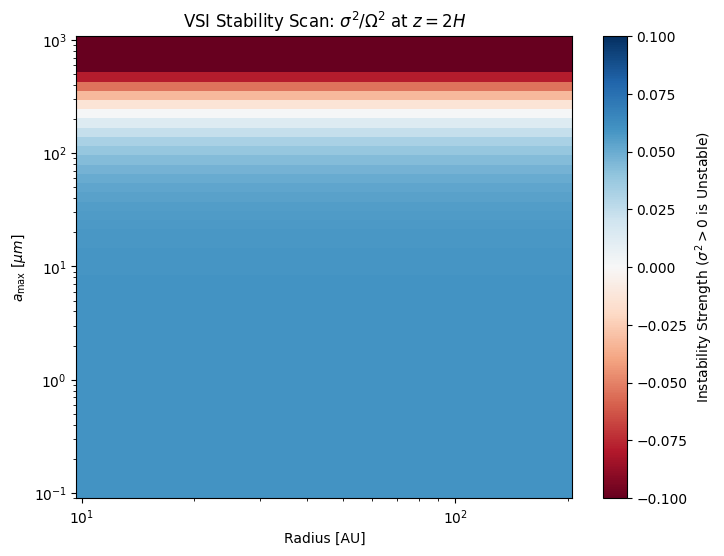

In [11]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- 1. CGS physical constants & Disk Parameters ---
KB = 1.380649e-16
MH = 2.4 * 1.6726219e-24
PLANCK = 6.62607015e-27
C_LIGHT = 2.99792458e10
STEFAN = 5.670374419e-5
G_CGS = 6.67430e-8
MSUN_CGS = 1.98847e33
AU_CM = 1.495978707e13

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36
cpgas = R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67 

# Disk Structure Constants
h = 0.06           # Aspect ratio H/R
q_index = 1.0      # Radial temperature gradient index
M_star = 1.0 * MSUN_CGS
R_ch = 30.0 * AU_CM
Sigma_ch = 6.4e-4 
z_height_H = 1.0   # Evaluation height for buoyancy

# --- 2. Supporting Functions ---
def calculate_dust_distribution(n_fluids, s_min, s_max, epsilon_total, q_slope=3.5):
    n_dust = n_fluids - 1
    a_plus = np.logspace(np.log10(s_min), np.log10(s_max), n_dust + 1)
    slope = 4.0 - q_slope
    
    if slope != 0.0:
        norm = epsilon_total / (s_max**slope - s_min**slope)
        epsilons = (a_plus[1:]**slope - a_plus[:-1]**slope) * norm
    else:
        norm = epsilon_total / np.log(s_max / s_min)
        epsilons = np.log(a_plus[1:] / a_plus[:-1]) * norm
        
    a_center = np.sqrt(a_plus[1:] * a_plus[:-1])
    return epsilons, a_center

# --- 3. Setup Scan Grid ---
n_bins = 5
a_min_cm = 1e-5
a_max_scan = np.logspace(np.log10(1e-5), np.log10(1e-1), 50)
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 50)
eps_total = 0.01
q_mrn = 3.5

ratio_map = np.zeros((len(a_max_scan), len(R_scan_cm)))
sigma2_map = np.zeros((len(a_max_scan), len(R_scan_cm)))

# --- 4. Two-Dimensional Physics Scan ---
for j, a_max_val in enumerate(a_max_scan):
    # Get dust weights for this a_max
    if a_max_val <= a_min_cm:
        eps_bins = np.array([eps_total])
        a_bins = np.array([a_min_cm])
    else:
        eps_bins, a_bins = calculate_dust_distribution(n_bins, a_min_cm, a_max_val, eps_total, q_mrn)
    
    inv_a = 1.0 / a_bins
    
    for i, r_cm in enumerate(R_scan_cm):
        # Local Gas Physics
        r_rel = r_cm / R_ch
        rho_g = (Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)) / r_rel
        temp_g = (h**2 * G_CGS * M_star / (R_ch * R_MU)) / r_rel
        om = np.sqrt(G_CGS * M_star / (R_ch**3)) / (r_rel**1.5)
        
        # Rule of thumb t_crit
        t_crit_local = h * q_index / ((gamma - 1.0) * om)
        
        # Dust Coupling (Alpha and Beta)
        alpha_bins = 0.75 * (KB / MH)**1.5 * np.sqrt(temp_g) * rho_g * inv_a / (rho_solid * cpdust)
        q_loc = 8.0 * np.pi * KB * temp_g / inv_a / (PLANCK * C_LIGHT)
        beta_bins = np.where(q_loc >= 1.0,
                            12.0 * inv_a / (rho_solid * cpdust) * STEFAN * (temp_g**3)/10.0,
                            np.pi * 120.0 * STEFAN * KB / (PLANCK * C_LIGHT * rho_solid * cpdust) * (temp_g**4)/10.0)
        
        # Effective Cooling Time (Integrated over 5 bins)
        t_cool_eff = np.sum((1) / (alpha_bins * eps_bins))
        ratio_map[j, i] = t_cool_eff / t_crit_local
        
        # --- VSI Growth Rate Calculation ---
        # 1. Un-damped Buoyancy at z=2H
        Nz2 = (gamma - 1.0) * (om**2) * (z_height_H**2)
        
        # 2. Shear Term (Destabilizing)
        H_loc = h * r_cm
        shear_term = np.abs(q_index) * (H_loc / r_cm) * (om**2)
        
        # 3. Apply Thermal Damping
        om_t = om * t_cool_eff
        Nz_eff2 = Nz2 * (om_t**2 / (1.0 + om_t**2))
        
        # 4. Resulting Growth Rate
        sigma2_map[j, i] = (shear_term - Nz_eff2) / (om**2)

# --- 5. Final Plotting (Growth Rate) ---
fig, ax = plt.subplots(figsize=(8, 6))
X, Y = np.meshgrid(R_scan_cm / AU_CM, a_max_scan * 1e4)
im = ax.pcolormesh(X, Y, sigma2_map, shading="auto", cmap="RdBu", vmin=-0.1, vmax=0.1)

# Cyan line marks the VSI Stability Boundary
# cs = ax.contour(X, Y, sigma2_map, levels=[0.0], colors='cyan', linewidths=2)
# plt.clabel(cs, fmt="VSI Stable Boundary", inline=True)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Radius [AU]")
ax.set_ylabel(r"$a_{\rm max}$ [$\mu m$]")
ax.set_title(r"VSI Stability Scan: $\sigma^2/\Omega^2$ at $z=2H$")
fig.colorbar(im, label=r"Instability Strength ($\sigma^2 > 0$ is Unstable)")
plt.show()

<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\e'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\e'
/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_7790/2050223712.py:66: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")
/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_7790/2050223712.py:66: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")


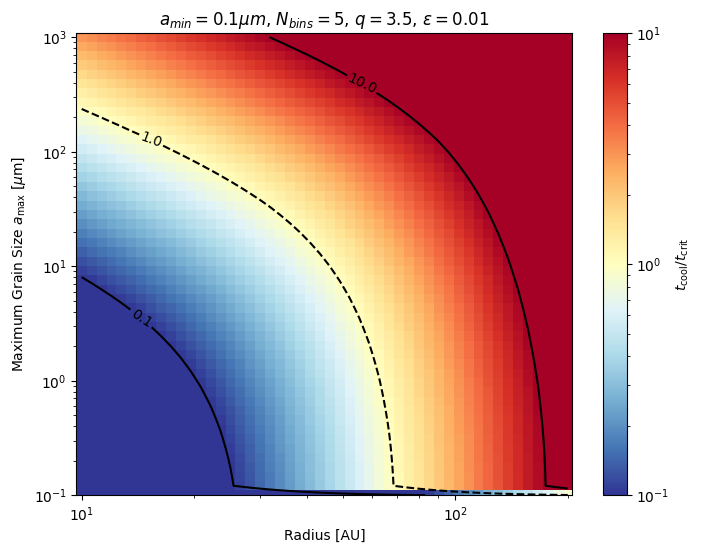

In [45]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- Setup Grid ---
n_bins = 5
q = 1
a_min_cm = 1e-5 # 0.1 micron
a_max_scan = np.logspace(np.log10(1e-5), np.log10(1e-1), 50) # scan a_max up to 1mm
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 50)
eps_total = 0.01
q_mrn = 3.5
R_ch = 30 * AU_CM
# Result array
ratio_map = np.zeros((len(a_max_scan), len(R_scan_cm)))

# --- Two-Dimensional Scan ---
for j, a_max_val in enumerate(a_max_scan):
    # Calculate the 5-bin weights for this specific a_max
    # If a_max == a_min, handle as a single bin
    if a_max_val <= a_min_cm:
        eps_bins = np.array([eps_total])
        a_bins = np.array([a_min_cm])
    else:
        eps_bins, a_bins = calculate_dust_distribution(n_bins, a_min_cm, a_max_val, eps_total, q_mrn)
    
    inv_a = 1.0 / a_bins
    
    for i, r_cm in enumerate(R_scan_cm):
        # Local Gas Physics at R
        r_rel = r_cm / R_ch
        rho_g = (Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)) / r_rel**2 #* (100/30)
        # print(rho_g)
        temp_g = (h**2 * G_CGS * M_star / (R_ch * R_MU)) / r_rel
        om = np.sqrt(G_CGS * M_star / (R_ch**3)) / (r_rel**1.5)
        t_crit_local = h*q / ((gamma - 1.0) * om)
        
        # Physics for the 5 bins
        alpha_bins = 0.75 * (KB / MH)**1.5 * np.sqrt(temp_g) * rho_g * inv_a / (rho_solid * cpdust)
        
        q_loc = 8.0 * np.pi * KB * temp_g / inv_a / (PLANCK * C_LIGHT)
        beta_bins = np.where(q_loc >= 1.0,
                            12.0 * inv_a / (rho_solid * cpdust) * STEFAN * (temp_g**3)/10.0,
                            np.pi * 120.0 * STEFAN * KB / (PLANCK * C_LIGHT * rho_solid * cpdust) * (temp_g**4)/10.0)
        
        # Summation: sum_i ((alpha + beta) / (alpha * beta * eps_i))
        col_sum= np.sum(1 / (alpha_bins *  eps_bins))
        beta_sum= np.sum(1 / (beta_bins *  eps_bins))
        tcol = np.sum((alpha_bins + beta_bins) / (eps_bins * alpha_bins * beta_bins ))
        ratio_map[j, i] = tcol / t_crit_local

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 6))
X, Y = np.meshgrid(R_scan_cm / AU_CM, a_max_scan * 1e4)
im = ax.pcolormesh(X, Y, ratio_map, shading="auto", cmap="RdYlBu_r", norm=mcolors.LogNorm(vmin=0.1, vmax=10))

# Critical Contours
ax.set_xscale("log")
ax.set_yscale("log")
cs = ax.contour(X, Y, ratio_map, levels=[0.1, 1.0, 10.0], colors='black', linestyles=['solid', 'dashed'])
plt.clabel(cs, inline=True, fontsize=10)


ax.set_xlabel("Radius [AU]")
ax.set_ylabel(r"Maximum Grain Size $a_{\rm max}$ [$\mu$m]")
ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")
fig.colorbar(im, label=r"$t_{\rm cool} / t_{\rm crit}$")
plt.show()

<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\e'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\e'
/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_7790/443440.py:66: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")
/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_7790/443440.py:66: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")


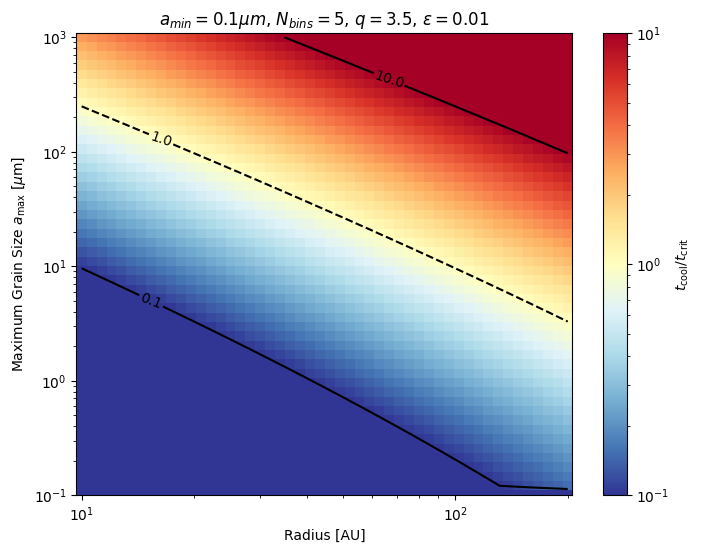

In [46]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- Setup Grid ---
n_bins = 5
q = 1
a_min_cm = 1e-5 # 0.1 micron
a_max_scan = np.logspace(np.log10(1e-5), np.log10(1e-1), 50) # scan a_max up to 1mm
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 50)
eps_total = 0.01
q_mrn = 3.5
R_ch = 30 * AU_CM
# Result array
ratio_map = np.zeros((len(a_max_scan), len(R_scan_cm)))

# --- Two-Dimensional Scan ---
for j, a_max_val in enumerate(a_max_scan):
    # Calculate the 5-bin weights for this specific a_max
    # If a_max == a_min, handle as a single bin
    if a_max_val <= a_min_cm:
        eps_bins = np.array([eps_total])
        a_bins = np.array([a_min_cm])
    else:
        eps_bins, a_bins = calculate_dust_distribution(n_bins, a_min_cm, a_max_val, eps_total, q_mrn)
    
    inv_a = 1.0 / a_bins
    
    for i, r_cm in enumerate(R_scan_cm):
        # Local Gas Physics at R
        r_rel = r_cm / R_ch
        rho_g = (Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)) / r_rel**2 #* (100/30)
        # print(rho_g)
        temp_g = (h**2 * G_CGS * M_star / (R_ch * R_MU)) / r_rel
        om = np.sqrt(G_CGS * M_star / (R_ch**3)) / (r_rel**1.5)
        t_crit_local = h*q / ((gamma - 1.0) * om)
        
        # Physics for the 5 bins
        alpha_bins = 0.75 * (KB / MH)**1.5 * np.sqrt(temp_g) * rho_g * inv_a / (rho_solid * cpdust)
        
        q_loc = 8.0 * np.pi * KB * temp_g / inv_a / (PLANCK * C_LIGHT)
        beta_bins = np.where(q_loc >= 1.0,
                            12.0 * inv_a / (rho_solid * cpdust) * STEFAN * (temp_g**3)/10.0,
                            np.pi * 120.0 * STEFAN * KB / (PLANCK * C_LIGHT * rho_solid * cpdust) * (temp_g**4)/10.0)
        
        # Summation: sum_i ((alpha + beta) / (alpha * beta * eps_i))
        col_sum= np.sum(1 / (alpha_bins *  eps_bins))
        beta_sum= np.sum(1 / (beta_bins *  eps_bins))
        tcol = np.sum((alpha_bins + beta_bins) / (eps_bins * alpha_bins * beta_bins ))
        ratio_map[j, i] = col_sum / t_crit_local

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 6))
X, Y = np.meshgrid(R_scan_cm / AU_CM, a_max_scan * 1e4)
im = ax.pcolormesh(X, Y, ratio_map, shading="auto", cmap="RdYlBu_r", norm=mcolors.LogNorm(vmin=0.1, vmax=10))

# Critical Contours
ax.set_xscale("log")
ax.set_yscale("log")
cs = ax.contour(X, Y, ratio_map, levels=[0.1, 1.0, 10.0], colors='black', linestyles=['solid', 'dashed'])
plt.clabel(cs, inline=True, fontsize=10)


ax.set_xlabel("Radius [AU]")
ax.set_ylabel(r"Maximum Grain Size $a_{\rm max}$ [$\mu$m]")
ax.set_title(f"$a_{{min}} = 0.1 \mu m$, $N_{{bins}}=5$, $q=3.5$, $\epsilon=0.01$")
fig.colorbar(im, label=r"$t_{\rm cool} / t_{\rm crit}$")
plt.show()

In [183]:
# Calculate the vertical buoyancy frequency Nz
# For a vertically isothermal disk:
# Nz^2 \approx (gamma - 1) * g_z / H_p (simplified)

g_z = omega**2 * Z  # Vertical gravity at height Z
Hp = h * R          # Pressure scale height

# Squared Brunt-Vaisala frequency
Nz2 = (gamma - 1) * (g_z**2 / (R_MU * T_gas))

# Normalize by local orbital frequency
buoyancy_ratio = np.sqrt(np.maximum(Nz2, 0)) / omega

# --- Plotting ---
plt.figure(figsize=(8, 5))
plt.plot(Z/Hp, buoyancy_ratio)
plt.axhline(1.0, color='k', linestyle='--', label='Strong Buoyancy Limit')
plt.xlabel('Height ($z/H$)')
plt.ylabel('$N_z / \Omega_K$')
plt.title('Vertical Buoyancy Profile for VSI Analysis')
plt.legend()
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\O'
<>:19: SyntaxWarning: invalid escape sequence '\O'
/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_50815/597038380.py:19: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$N_z / \Omega_K$')


NameError: name 'Z' is not defined

[[55.9139058  55.9139058  55.9139058  ... 55.9139058  55.9139058
  55.9139058 ]
 [55.31389593 55.31389593 55.31389593 ... 55.31389593 55.31389593
  55.31389593]
 [54.72032474 54.72032474 54.72032474 ... 54.72032474 54.72032474
  54.72032474]
 ...
 [15.82365156 15.82365156 15.82365156 ... 15.82365156 15.82365156
  15.82365156]
 [15.65384859 15.65384859 15.65384859 ... 15.65384859 15.65384859
  15.65384859]
 [15.48586777 15.48586777 15.48586777 ... 15.48586777 15.48586777
  15.48586777]]


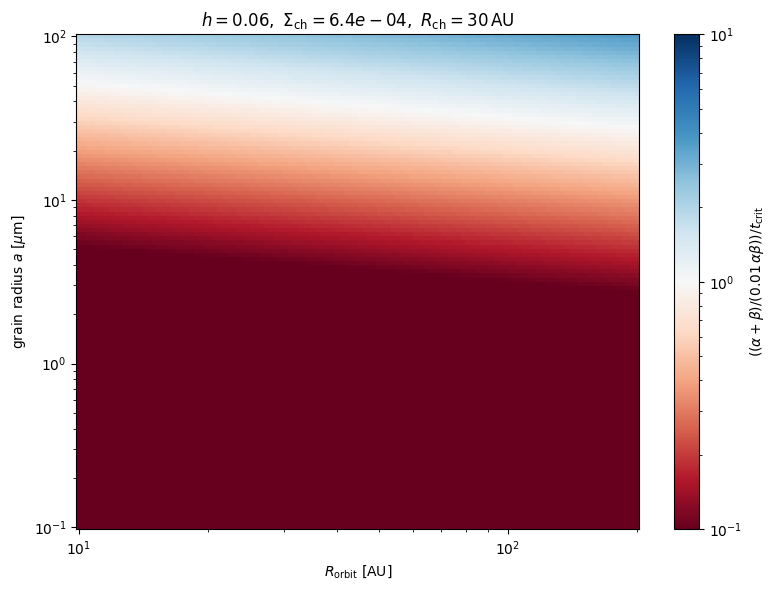

In [92]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS physical constants ---
KB = 1.380649e-16  # erg / K
MH = 2.4 * 1.6726219e-24  # g
PLANCK = 6.62607015e-27  # erg s
C_LIGHT = 2.99792458e10  # cm/s
STEFAN = 5.670374419e-5  # erg / (s cm^2 K^4)
G_CGS = 6.67430e-8  # cm^3 g^-1 s^-2
MSUN_CGS = 1.98847e33  # g
AU_CM = 1.495978707e13  # cm

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36

cpgas = R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67  # g/cm^3

# Variables
h = 0.06
M_star = 1.0 * MSUN_CGS
R_ch = 30.0 * AU_CM
Sigma_ch = 6.4*1e-4  # normalization at R_ch

# Grid of single-grain points: each (a, R) is one grain size at one orbit
a_scan_cm = np.logspace(np.log10(1e-1 * 1e-4), np.log10(100 * 1e-4), 120)
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 120)

A, R = np.meshgrid(a_scan_cm, R_scan_cm, indexing="xy")
inv_particlesize = 1.0 / A
r = R / R_ch

# rho(R) = rho_ch * r^-1, with r = R/R_ch and
# rho_ch anchored from the previous normalization at R_ch.
rho_ch = Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)
rho_gas = rho_ch / r

# T(R) = T_ch * r^-1
T_ch = h**2 * G_CGS * M_star / (R_ch * R_MU)
T_ch = 150 *np.power((R_ch * r/AU_CM), -3/7)
print(T_ch)
T_gas = T_ch / r
T_dust = T_gas

# Omega(R) = Omega_ch * r^-3 (requested scaling)
omega_ch = np.sqrt(G_CGS * M_star / (R_ch**3))
omega = omega_ch / (r**(3/2))
tcrit = h / ((gamma - 1.0) * omega)

alpha = (
    0.75
    * (KB / MH) ** 1.5
    * np.sqrt(T_gas)
    * rho_gas
    * inv_particlesize
    / (rho_solid * cpdust)
)

qlocal = 8.0 * np.pi * KB * T_dust / inv_particlesize / PLANCK / C_LIGHT
beta = np.empty_like(alpha)
mask_hi = qlocal >= 1.0
beta[mask_hi] = (
    12.0
    * inv_particlesize[mask_hi]
    / (rho_solid * cpdust)
    * STEFAN
    * (T_dust[mask_hi] ** 3.0)/12
)
mask_lo = ~mask_hi
beta[mask_lo] = (
    np.pi
    * 120.0
    * STEFAN
    * KB
    / (PLANCK * C_LIGHT * rho_solid * cpdust)
    * (T_dust[mask_lo] ** 4.0)/12
)
H = 0.1*h*R
eps = 0.005
tau = 3/4*0.01 * rho_gas / rho_solid * inv_particlesize *np.min(A*T_dust*1e4/600, 1) * H
ratio = (1 / (eps * alpha )) / tcrit

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    R_scan_cm / AU_CM,
    a_scan_cm * 1e4,
    ratio.T,
    shading="auto",
    cmap="RdBu",
    norm=mcolors.LogNorm(
        vmin=0.1,
        vmax=10,
    ),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$R_{\rm orbit}$ [AU]")
ax.set_ylabel(r"grain radius $a$ [$\mu$m]")
ax.set_title(
    r"$h=%.2f,\ \Sigma_{\rm ch}=%.1e,\ R_{\rm ch}=%.0f\,{\rm AU}$"
    % (h, Sigma_ch, R_ch / AU_CM)
)
fig.colorbar(im, ax=ax, label=r"$((\alpha+\beta)/(0.01\,\alpha\beta))/t_{\rm crit}$")
fig.tight_layout()
plt.show()


(0.0, 50.0)

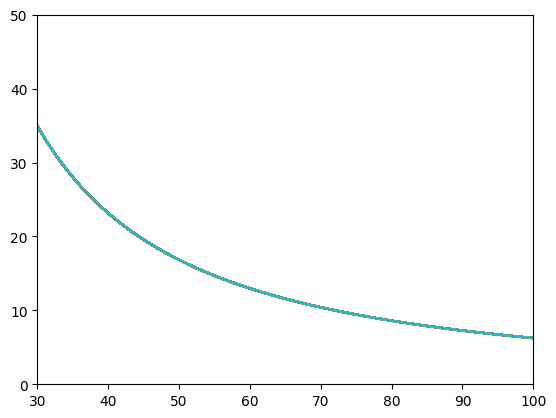

In [91]:
plot(R/AU_CM, T_gas)
plt.xlim(30 ,100)
plt.ylim(0 ,50)

[[55.9139058  55.9139058  55.9139058  ... 55.9139058  55.9139058
  55.9139058 ]
 [55.31389593 55.31389593 55.31389593 ... 55.31389593 55.31389593
  55.31389593]
 [54.72032474 54.72032474 54.72032474 ... 54.72032474 54.72032474
  54.72032474]
 ...
 [15.82365156 15.82365156 15.82365156 ... 15.82365156 15.82365156
  15.82365156]
 [15.65384859 15.65384859 15.65384859 ... 15.65384859 15.65384859
  15.65384859]
 [15.48586777 15.48586777 15.48586777 ... 15.48586777 15.48586777
  15.48586777]]


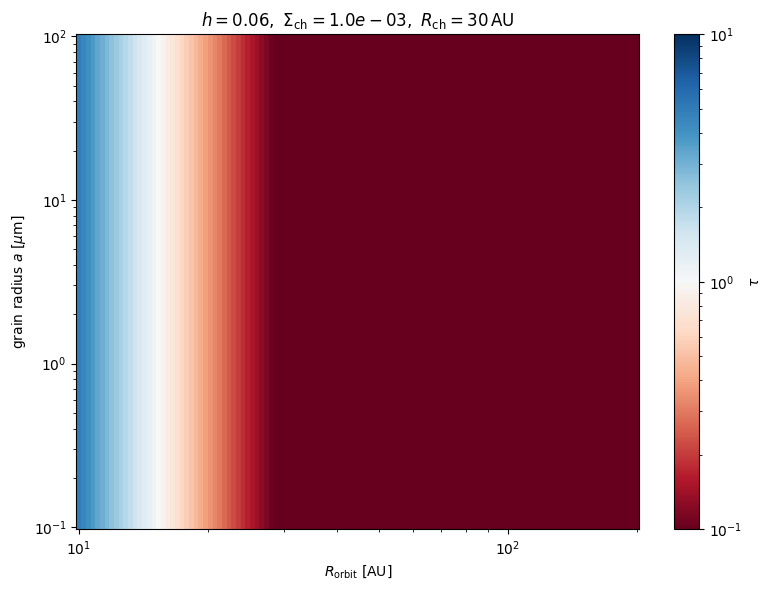

In [ ]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS physical constants ---
KB = 1.380649e-16  # erg / K
MH = 2.4 * 1.6726219e-24  # g
PLANCK = 6.62607015e-27  # erg s
C_LIGHT = 2.99792458e10  # cm/s
STEFAN = 5.670374419e-5  # erg / (s cm^2 K^4)
G_CGS = 6.67430e-8  # cm^3 g^-1 s^-2
MSUN_CGS = 1.98847e33  # g
AU_CM = 1.495978707e13  # cm

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36

cpgas = R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67  # g/cm^3

# Variables
h = 0.06
M_star = 1.0 * MSUN_CGS
R_ch = 30.0 * AU_CM
Sigma_ch = 1e-3  # normalization at R_ch

# Grid of single-grain points: each (a, R) is one grain size at one orbit
a_scan_cm = np.logspace(np.log10(1e-1 * 1e-4), np.log10(100 * 1e-4), 120)
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 120)

A, R = np.meshgrid(a_scan_cm, R_scan_cm, indexing="xy")
inv_particlesize = 1.0 / A
r = R / R_ch

# rho(R) = rho_ch * r^-1, with r = R/R_ch and
# rho_ch anchored from the previous normalization at R_ch.
rho_ch = Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)
rho_gas = rho_ch / r

# T(R) = T_ch * r^-1
T_ch = h**2 * G_CGS * M_star / (R_ch * R_MU)
T_ch = 150 *np.power((R_ch * r/AU_CM), -3/7)
print(T_ch)
T_gas = T_ch / r
T_dust = T_gas

# Omega(R) = Omega_ch * r^-3 (requested scaling)
omega_ch = np.sqrt(G_CGS * M_star / (R_ch**3))
omega = omega_ch / (r**(3/2))
tcrit = h / ((gamma - 1.0) * omega)

alpha = (
    0.75
    * (KB / MH) ** 1.5
    * np.sqrt(T_gas)
    * rho_gas
    * inv_particlesize
    / (rho_solid * cpdust)
)

qlocal = 8.0 * np.pi * KB * T_dust / inv_particlesize / PLANCK / C_LIGHT
beta = np.empty_like(alpha)
mask_hi = qlocal >= 1.0
beta[mask_hi] = (
    12.0
    * inv_particlesize[mask_hi]
    / (rho_solid * cpdust)
    * STEFAN
    * (T_dust[mask_hi] ** 3.0)
)
mask_lo = ~mask_hi
beta[mask_lo] = (
    np.pi
    * 120.0
    * STEFAN
    * KB
    / (PLANCK * C_LIGHT * rho_solid * cpdust)
    * (T_dust[mask_lo] ** 4.0)
)
H = 0.1*h*R
tau = 3/4*0.01 * rho_gas / rho_solid * inv_particlesize *np.min(A*T_dust*1e4/600, 1) * H
ratio = ((alpha + beta) / (0.01 * alpha * beta))*(1 + 3*tau**2) / tcrit

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    R_scan_cm / AU_CM,
    a_scan_cm * 1e4,
    tau,
    shading="auto",
    cmap="RdBu",
    norm=mcolors.LogNorm(
        vmin=0.1,
        vmax=10,
    ),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$R_{\rm orbit}$ [AU]")
ax.set_ylabel(r"grain radius $a$ [$\mu$m]")
ax.set_title(
    r"$h=%.2f,\ \Sigma_{\rm ch}=%.1e,\ R_{\rm ch}=%.0f\,{\rm AU}$"
    % (h, Sigma_ch, R_ch / AU_CM)
)
fig.colorbar(im, ax=ax, label=r"$\tau$")
fig.tight_layout()
plt.show()


[[55.9139058  55.9139058  55.9139058  ... 55.9139058  55.9139058
  55.9139058 ]
 [55.31389593 55.31389593 55.31389593 ... 55.31389593 55.31389593
  55.31389593]
 [54.72032474 54.72032474 54.72032474 ... 54.72032474 54.72032474
  54.72032474]
 ...
 [15.82365156 15.82365156 15.82365156 ... 15.82365156 15.82365156
  15.82365156]
 [15.65384859 15.65384859 15.65384859 ... 15.65384859 15.65384859
  15.65384859]
 [15.48586777 15.48586777 15.48586777 ... 15.48586777 15.48586777
  15.48586777]]


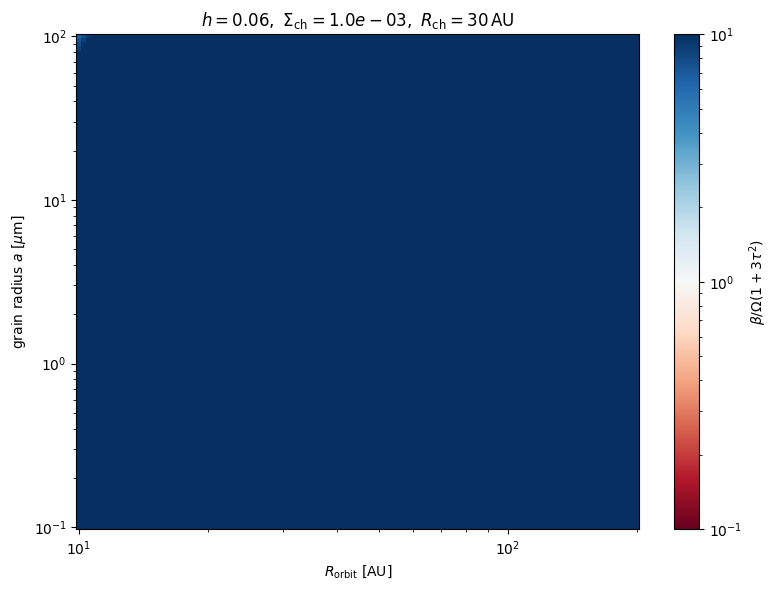

In [81]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS physical constants ---
KB = 1.380649e-16  # erg / K
MH = 2.4 * 1.6726219e-24  # g
PLANCK = 6.62607015e-27  # erg s
C_LIGHT = 2.99792458e10  # cm/s
STEFAN = 5.670374419e-5  # erg / (s cm^2 K^4)
G_CGS = 6.67430e-8  # cm^3 g^-1 s^-2
MSUN_CGS = 1.98847e33  # g
AU_CM = 1.495978707e13  # cm

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36

cpgas = R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67  # g/cm^3

# Variables
h = 0.06
M_star = 1.0 * MSUN_CGS
R_ch = 30.0 * AU_CM
Sigma_ch = 1e-3  # normalization at R_ch

# Grid of single-grain points: each (a, R) is one grain size at one orbit
a_scan_cm = np.logspace(np.log10(1e-1 * 1e-4), np.log10(100 * 1e-4), 120)
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 120)

A, R = np.meshgrid(a_scan_cm, R_scan_cm, indexing="xy")
inv_particlesize = 1.0 / A
r = R / R_ch

# rho(R) = rho_ch * r^-1, with r = R/R_ch and
# rho_ch anchored from the previous normalization at R_ch.
rho_ch = Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)
rho_gas = rho_ch / r

# T(R) = T_ch * r^-1
T_ch = h**2 * G_CGS * M_star / (R_ch * R_MU)
T_ch = 150 *np.power((R_ch * r/AU_CM), -3/7)
print(T_ch)
T_gas = T_ch / r
T_dust = T_gas

# Omega(R) = Omega_ch * r^-3 (requested scaling)
omega_ch = np.sqrt(G_CGS * M_star / (R_ch**3))
omega = omega_ch / (r**(3/2))
tcrit = h / ((gamma - 1.0) * omega)

alpha = (
    0.75
    * (KB / MH) ** 1.5
    * np.sqrt(T_gas)
    * rho_gas
    * inv_particlesize
    / (rho_solid * cpdust)
)

qlocal = 8.0 * np.pi * KB * T_dust / inv_particlesize / PLANCK / C_LIGHT
beta = np.empty_like(alpha)
mask_hi = qlocal >= 1.0
beta[mask_hi] = (
    12.0
    * inv_particlesize[mask_hi]
    / (rho_solid * cpdust)
    * STEFAN
    * (T_dust[mask_hi] ** 3.0)
)
mask_lo = ~mask_hi
beta[mask_lo] = (
    np.pi
    * 120.0
    * STEFAN
    * KB
    / (PLANCK * C_LIGHT * rho_solid * cpdust)
    * (T_dust[mask_lo] ** 4.0)
)
H = 0.1*h*R
tau = 3/4*0.01 * rho_gas / rho_solid * inv_particlesize *np.min(A*T_dust*1e4/600, 1) * H
ratio = ((alpha + beta) / (0.01 * alpha * beta))*(1 + 3*tau**2) / tcrit

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    R_scan_cm / AU_CM,
    a_scan_cm * 1e4,
    beta/(1 + 3*tau**2)/omega,
    shading="auto",
    cmap="RdBu",
    norm=mcolors.LogNorm(
        vmin=0.1,
        vmax=10,
    ),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$R_{\rm orbit}$ [AU]")
ax.set_ylabel(r"grain radius $a$ [$\mu$m]")
ax.set_title(
    r"$h=%.2f,\ \Sigma_{\rm ch}=%.1e,\ R_{\rm ch}=%.0f\,{\rm AU}$"
    % (h, Sigma_ch, R_ch / AU_CM)
)
fig.colorbar(im, ax=ax, label=r"$\beta /\Omega (1 + 3\tau^2)$")
fig.tight_layout()
plt.show()

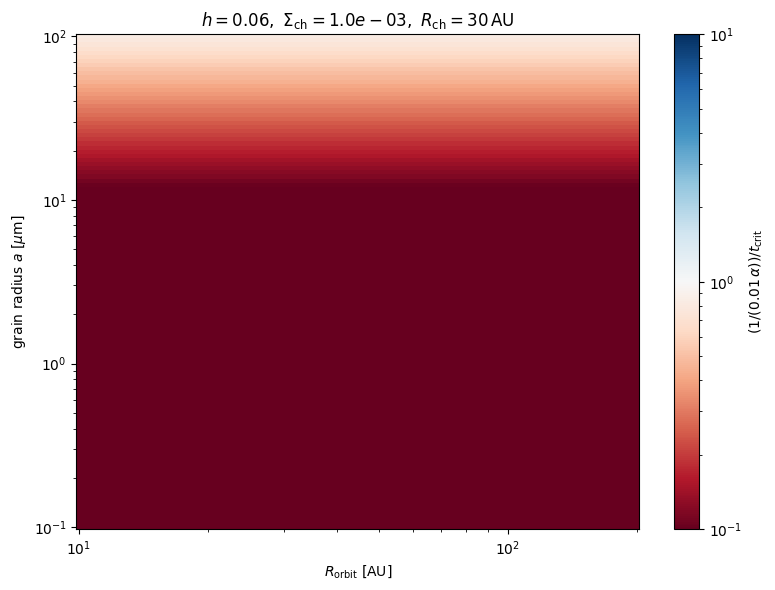

In [60]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- CGS physical constants ---
KB = 1.380649e-16  # erg / K
MH = 2.4 * 1.6726219e-24  # g
PLANCK = 6.62607015e-27  # erg s
C_LIGHT = 2.99792458e10  # cm/s
STEFAN = 5.670374419e-5  # erg / (s cm^2 K^4)
G_CGS = 6.67430e-8  # cm^3 g^-1 s^-2
MSUN_CGS = 1.98847e33  # g
AU_CM = 1.495978707e13  # cm

gamma = 1.4
CPDG = 0.088
R_MU = 34447318.36

cpgas = R_MU / (gamma - 1.0)
cpdust = CPDG * cpgas
rho_solid = 1.67  # g/cm^3

# Variables
h = 0.06
M_star = 1.0 * MSUN_CGS
R_ch = 30.0 * AU_CM
Sigma_ch = 1e-3  # normalization at R_ch

# Grid of single-grain points: each (a, R) is one grain size at one orbit
a_scan_cm = np.logspace(np.log10(1e-1 * 1e-4), np.log10(100 * 1e-4), 120)
R_scan_cm = np.logspace(np.log10(10.0 * AU_CM), np.log10(200.0 * AU_CM), 120)

A, R = np.meshgrid(a_scan_cm, R_scan_cm, indexing="xy")
inv_particlesize = 1.0 / A
r = R / R_ch

# rho(R) = rho_ch * r^-1, with r = R/R_ch and
# rho_ch anchored from the previous normalization at R_ch.
rho_ch = Sigma_ch * (M_star / R_ch**3) / (np.sqrt(2.0 * np.pi) * h)
rho_gas = rho_ch / r

# T(R) = T_ch * r^-1
T_ch = h**2 * G_CGS * M_star / (R_ch * R_MU)
T_gas = T_ch / r
T_dust = T_gas

# Omega(R) = Omega_ch * r^-3 (requested scaling)
omega_ch = np.sqrt(G_CGS * M_star / (R_ch**3))
omega = omega_ch / (r**(3/2))
tcrit = h / ((gamma - 1.0) * omega)

alpha = (
    0.75
    * (KB / MH) ** 1.5
    * np.sqrt(T_gas)
    * rho_gas
    * inv_particlesize
    / (rho_solid * cpdust)
)

qlocal = 8.0 * np.pi * KB * T_dust / inv_particlesize / PLANCK / C_LIGHT
beta = np.empty_like(alpha)
mask_hi = qlocal >= 1.0
beta[mask_hi] = (
    12.0
    * inv_particlesize[mask_hi]
    / (rho_solid * cpdust)
    * STEFAN
    * (T_dust[mask_hi] ** 3.0)*1000000
)
mask_lo = ~mask_hi
beta[mask_lo] = (
    np.pi
    * 120.0
    * STEFAN
    * KB
    / (PLANCK * C_LIGHT * rho_solid * cpdust)
    * (T_dust[mask_lo] ** 4.0)*1000000
)

ratio = (1 / (0.01 * alpha)) / tcrit

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    R_scan_cm / AU_CM,
    a_scan_cm * 1e4,
    ratio.T,
    shading="auto",
    cmap="RdBu",
    norm=mcolors.LogNorm(
        vmin=0.1,
        vmax=10,
    ),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$R_{\rm orbit}$ [AU]")
ax.set_ylabel(r"grain radius $a$ [$\mu$m]")
ax.set_title(
    r"$h=%.2f,\ \Sigma_{\rm ch}=%.1e,\ R_{\rm ch}=%.0f\,{\rm AU}$"
    % (h, Sigma_ch, R_ch / AU_CM)
)
fig.colorbar(im, ax=ax, label=r"$(1/(0.01\,\alpha))/t_{\rm crit}$")
fig.tight_layout()
plt.show()


In [289]:
print(np.sqrt((100 * AU_CM)**3 /(G_cgs * 2e33) )/3e7)

166.9356163677746
